# <font color="#6e8ebc">**CusTech - Exploratory Data Analysis**</font>
---

## <font color='#b0aeae'>**Índice**</font>

1. <font color="#6e8ebc">**Descripción del Notebook**</font>
2. <font color="#6e8ebc">**Configuraciónes**</font>
   * Importación de librerías
   * Paths
   * Paleta de Colores del Proyecto
   * Funciones
3. <font color="#6e8ebc">**Extracción de datos**</font>
   * Clientes
   * Transacciones
   * Interacciones con la App
4. <font color="#6e8ebc">**Exploratory Data Analysis (EDA)**</font>
   * Perfil del cliente
   * Transacciones del cliente
   * Interacciones del cliente con la App
5. <font color="#6e8ebc">**Feature Engineering**</font>
   * Datasets Integration
   * Variance Inflation Factor (VIF)

# <font color="#6e8ebc">**Descripción del Notebook**</font>

# <font color="#6e8ebc">**Cofiguraciones**</font>

## <font color="#ff743d">**Importación de librerías**</font>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import requests
import json

import os
from typing import Callable, List, Dict, Tuple
from pathlib import Path

from IPython.display import clear_output
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## <font color="#ff743d">**Paths**</font>

In [2]:
# Obtiene el path actual
PROJECT_PATH = os.getcwd()

src = Path('src')
DATA_PATH = PROJECT_PATH / src

img = Path('img')
GENERAL_IMG_PATH = PROJECT_PATH / img

EDA_img = Path('EDA_img')
IMG_PATH = GENERAL_IMG_PATH / EDA_img

reports = Path('reports')
REPORTS_PATH = PROJECT_PATH / reports

dirs = [DATA_PATH, IMG_PATH, REPORTS_PATH]


for directory in dirs:
    if not directory.exists():
        directory.mkdir(parents=True)
        print(f'Directorio creado:\n{directory}\n')
    else:
        print(f'El directorio ya existe:\n{directory}\n')

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\src

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\img\EDA_img

El directorio ya existe:
C:\Users\Ignacio\OneDrive\Desktop\hackathon_ONE\churn-insight-ml\reports



## <font color="#ff743d">**Paleta de Colores del Proyecto**</font>

**Naranjas**

<span style="display:inline-block; width:20px; height:20px; background:#993c00; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#cc5a00; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ff7b00; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ff9c40; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ffbf80; margin-right:5px;"></span>

**Rojos**

<span style="display:inline-block; width:20px; height:20px; background:#7a1c00; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#b23200; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#e74903; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ff743d; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#ffa68c; margin-right:5px;"></span>

**Azules**

<span style="display:inline-block; width:20px; height:20px; background:#001a37; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#002b5c; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#003873; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#315c99; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#6e8ebc; margin-right:5px;"></span>

**Celestes**

<span style="display:inline-block; width:20px; height:20px; background:#004752; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#007789; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#00b5d0; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#40cee6; margin-right:5px;"></span>
<span style="display:inline-block; width:20px; height:20px; background:#8ae6f4; margin-right:5px;"></span>

In [3]:
NARANJA_1, NARANJA_2, NARANJA_3, NARANJA_4, NARANJA_5 = '#993c00', '#cc5a00', '#ff7b00', '#ff9c40', '#ffbf80'
ROJO_1, ROJO_2, ROJO_3, ROJO_4, ROJO_5 = '#7a1c00', '#b23200', '#e74903', '#ff743d', '#ffa68c'
AZUL_1, AZUL_2, AZUL_3, AZUL_4, AZUL_5 = '#001a37', '#002b5c', '#003873', '#315c99', '#6e8ebc'
CIELO_1, CIELO_2, CIELO_3, CIELO_4, CIELO_5 = '#004752', '#007789', '#00b5d0', '#40cee6', '#8ae6f4'

## <font color="#ff743d">**Funciones**</font>

In [4]:
exited_colors = [CIELO_2, NARANJA_3]

In [5]:
def boxplot_exited(df: pd.DataFrame,
                  ycol: str,
                  ylabel: str=None,
                  path='.'):
    """    
    Genera y guarda un diagrama de caja (boxplot) con la distribución de una característica numérica ('ycol')
    diferenciada según la condición de abandono ('Exited').
    --------------------------------------------------------------------------------------------------
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame que contiene los datos para graficar. Debe incluir las columnas 'Exited' y <'ycol'>.
    ycol : str
        Nombre de la columna numérica a visualizar.
    ylabel : str, opcional
        Etiqueta personalizada para el eje Y. Si no se especifica, se usará el nombre de 'ycol'.
    --------------------------------------------------------------------------------------------------
    Guardado
    --------
    Guarda el gráfico como imagen PNG en la ruta './<path>/' bajo el nombre 'boxplot_Exited_<ycol>.png'. 
    --------------------------------------------------------------------------------------------------
    Retorna
    -------
    fig: matplotlib.figure.Figure
        Objeto Figure de Matplotlib con el gráfico generado.
    """

    if ylabel is None:
        ylabel = ycol
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax = sns.boxplot(data=df, x='Exited', y=ycol, hue='Exited', palette=exited_colors)
    plt.title(f'Distribución {ycol} según Exited', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Exited', fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.xticks(fontsize=13)
    plt.grid(True)
    
    fig.savefig(path/f'boxplot_Exited_{ycol}.png',
                transparent=False,
                dpi=300,
                bbox_inches='tight')
    plt.show()
    return fig

In [6]:
def histograma_exited(df, 
                     xcol, 
                     xlabel: str=None,
                     path: Path='.'):
    """
    Genera y guarda un histograma doble con la distribución de una variable numérica ('xcol'),
    diferenciada por la condición de abandono ('Exited' = 1 y 0).
    --------------------------------------------------------------------------------------------------
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame que contiene los datos a graficar. Debe incluir la columna 'Exited' y la columna numérica <'xcol'>.
    xcol : str
        Nombre de la columna numérica a visualizar.
    xlabel : str, opcional
        Etiqueta personalizada para el eje X. Si no se especifica, se usará el nombre de 'xcol'.
    --------------------------------------------------------------------------------------------------
    Guardado
    --------
    Guarda el gráfico como imagen PNG en la ruta './<path>/' bajo el nombre 'hist_Churn_<xcol>.png'.
    --------------------------------------------------------------------------------------------------
    Retorna
    -------
    fig : matplotlib.figure.Figure
        Objeto Figure de Matplotlib con los gráficos generados.
    """

    if xlabel is None:
        xlabel = xcol
        
    fig, axes = plt.subplots(2,1, figsize=(8,6))

    sns.histplot(data=df[df['Exited'] == 0], x=xcol, bins=30, color=exited_colors[0], kde=True, ax=axes[0])
    axes[0].set_title("Exited = 0", fontsize=15, fontweight='bold', loc='left', color=CIELO_3)
    axes[0].set_xlabel(xlabel, fontsize=13)
    axes[0].set_ylabel('Frecuencia', fontsize=13)
    
    sns.histplot(data=df[df['Exited'] == 1], x=xcol, bins=30,  color=exited_colors[1], kde=True, ax=axes[1])
    axes[1].set_title("Exited = 1", fontsize=15, fontweight='bold', loc='left', color=NARANJA_4)
    axes[1].set_xlabel(xlabel, fontsize=13)
    axes[1].set_ylabel('Frecuencia', fontsize=13)

    # Ajuste de los límites de los ejes
    ymax1 = axes[0].get_ylim()[1]
    ymax2 = axes[1].get_ylim()[1]

    ymax = max(ymax1, ymax2)

    axes[0].set_ylim(0, ymax)
    axes[1].set_ylim(0, ymax)

    # Configuraciones

    sns.despine()
    plt.suptitle(f'Distribución {xlabel} según Exited', fontsize=18, fontweight='bold', y=1.01)
    plt.subplots_adjust(hspace=2)
    plt.tight_layout()
    
    fig.savefig(f'{path}/hist_Extied_{xcol}.png',
                    transparent=False,
                    dpi=300,
                    bbox_inches='tight')
    
    plt.show()
    return fig


In [7]:
def bar_exited(df: pd.DataFrame,
              xcol: str,
              ycol: str='count',
              hue_col: str='Exited',
              figsize: Tuple=(6,4),
              xlabel: str=None,
              ylabel: str='Customer Count',
              rotation: float=None,
              path: Path='.'):
    
    """
    Genera y guarda un gráfico de barras agrupadas para comparar las clases de una variable categórica ('xcol'),
    diferenciadas según la condición de abandono ('Exited'), utilizando la frecuencia u otra métrica como altura.
    --------------------------------------------------------------------------------------------------
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame que contiene los datos a graficar. Debe incluir la columna 'Exited' y la columna categórica <'xcol'>.
    xcol : str
        Columna categórica que se representa en el eje X.
    ycol : str, opcional
        Columna numérica para el eje Y. (Por defecto: 'count').
    hue_col : str, opcional
        Columna utilizada para agrupar los datos. (Por defecto: 'Exited').
    figsize : Tuple, opcional
        Tamaño de la figura en pulgadas (ancho, alto). (Por defecto: (6, 4)).
    xlabel : str, opcional
        Etiqueta del eje X. Si no se especifica, se usará el nombre de 'xcol'.
    ylabel : str, opcional
        Etiqueta del eje Y. (Por defecto: 'Customer Count').
    --------------------------------------------------------------------------------------------------
    Guardado
    --------
    Guarda el gráfico como imagen PNG en la ruta './<path>/' bajo el nombre 'bar_Churn_<xcol>.png'.
    --------------------------------------------------------------------------------------------------
    Retorna
    -------
    fig : matplotlib.figure.Figure
        Objeto Figure de Matplotlib con el gráfico de barras generado.
    """

    df_counts = pd.DataFrame(df_clients.groupby([xcol, hue_col])[xcol].value_counts()).reset_index()


    fig, ax = plt.subplots(figsize=figsize)
    
        
    ax = sns.barplot(data=df_counts, x=xcol, y=ycol, hue=hue_col, palette=exited_colors)
    ax.set_title(f'Exited según {xcol}', fontsize=18, fontweight='bold', pad=20)
    if xlabel is None:
        ax.set_xlabel('')
    else:
        ax.set_xlabel(xcol, fontsize=15)
        
    ax.set_ylabel(ylabel, fontsize=15)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=12, labelrotation=rotation)
    for bar in ax.patches:
        height = bar.get_height()
        if height == 0:
            continue
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, 
                    height + 30,
                    f'{height:.0f}',
                    ha='center')
            
    sns.despine()


    fig.savefig(path/f'bar_Exited_{xcol}.png',
                transparent=False,
                dpi=300,
                bbox_inches='tight')

    plt.show()
    return fig


In [8]:
def pivot_and_exited_rate(df: pd.DataFrame, 
                          index_col: str):
    """
    Genera una tabla resumen con la tasa de abandono ('Exited rate') por clases de una variable categórica.

    Transforma un DataFrame con las columnas 'Exited' y 'count' en una tabla dinámica donde cada fila
    representa una categoría de 'index_col', con columnas separadas para cada valor de 'Exited'.
    Calcula la tasa de abandono y ordena los resultados en orden descendente.
    --------------------------------------------------------------------------------------------------
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con las columnas 'Exited' y 'count', que además contiene la variable categórica indicada
        en 'index_col'.
    index_col : str
        Nombre de la columna categórica que se utiliza como índice.
    --------------------------------------------------------------------------------------------------
    Retorna
    -------
    df : pd.DataFrame
        DataFrame con las columnas:
        - 'index_col': variable categórica evaluada
        - 'No Exited': cantidad de clientes que no cancelaron sus servicios
        - 'Exited': cantidad de clientes que cancelaron sus servicios
        - 'Exit Rate (%)': tasa de abandono para cada clase
    """
    
    df = df.pivot(index=index_col, columns='Exited', values='count')
    df.columns = ['No Exited', 'Exited']
    df = df.reset_index()
    df['Exit Rate (%)'] = round(df['Exited'] / (df['Exited'] + df['No Exited']) * 100, 2)
    df = df.sort_values(by='Exit Rate (%)', ascending=False)
    return df

In [9]:
def plot_exited_rate_table(df: pd.DataFrame,
                          col: str,
                          rate_col: str='Exit Rate (%)',
                          figsize: Tuple=(6,3),
                          save_as: str=None,
                          path: Path='.'):

    """
    Genera una tabla visual (usando Matplotlib) para mostrar la tasa de abandono ('Exit Rate') 
    por clases de una variable categórica.

    La función construye una tabla gráfica basada en una columna categórica ('col') y su respectiva 
    tasa de abandono, resaltando en rojo la clase con la tasa más alta.
    Luego, la tabla se exporta automáticamente como una imagen PNG.
    --------------------------------------------------------------------------------------------------
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame que contiene 'col' y una columna con la tasa de abandono. (Por defecto: 'Exit Rate (%)').
    col : str
        Nombre de la variable categórica cuyas clases se mostrarán en la tabla.
    rate_col : str, opcional
        Nombre de la columna que contiene los valores de la tasa de abandono. (Por defecto: 'Exit Rate (%)').
    figsize : Tuple, opcional
        Tamaño de la figura en pulgadas (ancho, alto). (Por defecto: (6, 3)).
    save_as: str, opcional
        Nombre con el que se guardará la figura. (Por defecto: el nombre de 'col').
    --------------------------------------------------------------------------------------------------
    Retorna
    -------
    fig : matplotlib.figure.Figure
        Objeto Figure de Matplotlib con la tabla renderizada.
    """

    if rate_col != 'Exit Rate (%)':
        label = rate_col
    else:
        label = 'Exit Rate (%)'
    
    data = df[[col, rate_col]].values.tolist()

    if save_as is None:
        save_as = col

    # Crear tabla para exportar como imagen
    fig, ax = plt.subplots(figsize=figsize)
    # Eliminar ejes
    ax.axis('off')
    
    color_order = []
    max_rate = max(data, key=lambda x: x[1])
    idx_max = data.index(max_rate)
    
    for i in range(len(df)):
        if i == idx_max:
            color_order.append('tomato')
        else:
            color_order.append('silver')
            
    cell_colors = [[color, color] for color in color_order]

    tabla = ax.table(cellText=data,
                     colLabels=[col, label],
                     cellLoc='center',
                     loc='center',
                     colColours=['gray' for i in range(len(data[0]))],
                     cellColours=cell_colors)
    
    plt.title(f'Exit Rate (%) según {col}', fontsize=18, fontweight='bold', pad=20)
    
    # Escalar la tabla para una mejor legibilidad
    tabla.scale(1, 2)
    
    plt.tight_layout()
    
    fig.savefig(path/f'exit_rate_{save_as}.png',
                transparent=False,
                dpi=300,
                bbox_inches='tight')
    
    
    plt.show()
    return fig

In [10]:
def barh_stack_exited(df: pd.DataFrame,
                     ycol: str,
                     figsize: Tuple=(8,3),
                     path: Path='.'):

    """
    Genera un gráfico de barras horizontales apiladas para mostrar la distribución de clientes 
    según una variable categórica y la condición de abandono ('Exited').
    (Utilizar la función pivot_and_exited_rate sobre el DataFrame antes de usar esta función)

    Este gráfico muestra la composición de cada clase de 'ycol' según la condición de abandono.
    La figura se guarda automáticamente como imagen PNG.
    --------------------------------------------------------------------------------------------------
    Parámetros
    ----------
    df : pd.DataFrame
        El DataFrame debe contener las columnas 'No Exited', 'Exited' y la columna categórica '<ycol>'.
    ycol : str
        Nombre de la columna categórica utilizada en el eje Y.
    figsize : Tuple, opcional
        Tamaño de la figura en pulgadas (ancho, alto). (Por defecto: (8, 3)).
    --------------------------------------------------------------------------------------------------
    Retorna
    -------
    fig: matplotlib.figure.Figure
        Objeto Figure de Matplotlib.
    """

        
    fig, ax = plt.subplots(figsize=figsize)
    
    ax.set_frame_on(False)

    df['Total'] = df['No Exited'] + df['Exited']
    df.sort_values(by='Total', inplace=True)
    # Barras horizontales
    ax.barh(df[ycol], df['No Exited'], label='No Exited', color=exited_colors[0])
    ax.barh(df[ycol], df['Exited'], left=df['No Exited'], label='Exited', color=exited_colors[1])
    
    for idx, row in df.iterrows():
        tipo = row[ycol]
        
        # Etiqueta para "No Exited"
        no_exited = row['No Exited'] / 2
        ax.text(no_exited, tipo, str(row['No Exited']), va='center', ha='center', color='black', fontsize=9)
        
        # Etiqueta para "Exited"
        exited = row['No Exited'] + row['Exited'] / 2
        ax.text(exited, tipo, str(row['Exited']), va='center', ha='center', color='black', fontsize=9)
    
    # Título y etiquetas
    ax.set_title(f'Exited by {ycol}', fontsize=18, loc='left', fontweight='bold', pad=20)
    ax.xaxis.set_visible(False)
    ax.tick_params(size=0, labelsize=10)
    ax.legend()
    sns.despine()
    
    plt.tight_layout()
    
    fig.savefig(path/f'barhstk_Exited_{ycol}.png',
                transparent=False,
                dpi=300,
                bbox_inches='tight')
    
    plt.show()
    return fig

In [11]:
def kde_density_exited(df: pd.DataFrame,
                        xcol: str='date',
                        ycol: str=None,
                        figsize: Tuple=(9,6),
                        title: str=None,
                        path: Path='.'):
    
    """
    Genera y guarda un gráfico de densidad de kernel (KDE) para visualizar la distribución 
    de una o dos variables según la condición de abandono ('Exited').
    
    El gráfico muestra las curvas de densidad sombreadas para los clientes que
    abandonaron el servicio y los que no. Es ideal para analizar cómo las variables
    continuas se distribuyen en ambos grupos.

    --------------------------------------------------------------------------------------------------
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame que contiene los datos a graficar. Debe incluir las columnas 'Exited', 
        '<xcol>' y opcionalmente '<ycol>'.
    xcol : str, opcional
        Nombre de la columna numérica o de fecha para el eje X. (Por defecto: 'date').
    ycol : str, opcional
        Nombre de la columna numérica para el eje Y. Si se especifica, el gráfico 
        será de densidad 2D. (Por defecto: None).
    figsize : Tuple, opcional
        Tamaño de la figura en pulgadas (ancho, alto). (Por defecto: (9, 6)).
    title : str, opcional
        Título personalizado para el gráfico. Si no se especifica, el título se 
        generará automáticamente a partir de 'ycol'. (Por defecto: None).
    path : Path, opcional
        Ruta donde se guardará la imagen. (Por defecto: '.').

    --------------------------------------------------------------------------------------------------
    Guardado
    --------
    Guarda el gráfico como imagen PNG en la ruta './<path>/' bajo el nombre
    'sessions_density_sampled.png'.

    --------------------------------------------------------------------------------------------------
    Retorna
    -------
    None
        Esta función no retorna ningún valor explícito.
    """

    if title is None:
        title = ycol
    
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.kdeplot(
        data=df,
        x=xcol,
        hue='Exited',
        fill=True,
        common_norm=False,
        palette=exited_colors,
        alpha=0.5,
        linewidth=2,
        ax=ax
    )
    
    plt.title(f'Densidad de {title} en el tiempo según Exited', fontsize=18, fontweight='bold')
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Densidad', fontsize=16)
    plt.xticks(rotation=45)
    
    sns.despine()
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    plt.savefig(path / f'{title}_density_sampled.png', dpi=300)
    plt.show()
    return fig

# <font color="#6e8ebc">**Extracción de Datos**</font>

In [12]:
clients = Path('clients.parquet')
tx = Path('transactions.parquet')
ss = Path('app_sessions.parquet')

In [13]:
df_clients = pd.read_parquet(DATA_PATH / clients)
df_tx = pd.read_parquet(DATA_PATH / tx)
df_ss = pd.read_parquet(DATA_PATH / ss)

## <font color="#ff743d">**Exploración de Datasets**</font>

### <font color="#ffbf80">**Clientes**</font>

In [14]:
df_clients

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ExitDate,CustomerSegment
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2025-11-15,Cliente potencial
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NaT,Standard
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2025-12-28,VIP
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaT,Poco Valor
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NaT,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,NaT,Cliente potencial
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,NaT,Valioso - Bajo compromiso
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,2025-12-18,Poco Valor
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2025-11-28,Standard


In [15]:
df_clients.drop(['RowNumber', 'Surname'], axis=1, inplace=True)

In [16]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerId       10000 non-null  int64         
 1   CreditScore      10000 non-null  int64         
 2   Geography        10000 non-null  object        
 3   Gender           10000 non-null  object        
 4   Age              10000 non-null  int64         
 5   Tenure           10000 non-null  int64         
 6   Balance          10000 non-null  float64       
 7   NumOfProducts    10000 non-null  int64         
 8   HasCrCard        10000 non-null  int64         
 9   IsActiveMember   10000 non-null  int64         
 10  EstimatedSalary  10000 non-null  float64       
 11  Exited           10000 non-null  int64         
 12  ExitDate         2037 non-null   datetime64[ns]
 13  CustomerSegment  10000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64

In [17]:
df_clients['CustomerId'] = df_clients['CustomerId'].astype(str)

In [18]:
df_clients['Exited'].sum()

2037

In [19]:
categorical = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember',
                   'CustomerSegment']

print('\n==============================')
print('     VARIABLES CATEGÓRICAS')
print('==============================')
for col in categorical:
    print(f'\n{col} unique values:\n{df_clients[col].unique()}')


     VARIABLES CATEGÓRICAS

Geography unique values:
['France' 'Spain' 'Germany']

Gender unique values:
['Female' 'Male']

HasCrCard unique values:
[1 0]

IsActiveMember unique values:
[1 0]

CustomerSegment unique values:
['Cliente potencial' 'Standard' 'VIP' 'Poco Valor'
 'Valioso - Bajo compromiso']


In [20]:
numerical = ['CreditScore', 'Age', 'Tenure', 'Balance',
                   'NumOfProducts', 'EstimatedSalary']

df_clients[numerical].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


### <font color="#ffbf80">**Transacciones**</font>

In [21]:
df_tx.head()

,TransactionId,CustomerId,TransactionDate,Amount,TransactionType
0,219905,15762110,2025-01-01,2888.57,TRANSFER
1,1298785,15586674,2025-01-01,354.10,PAYMENT
2,807648,15569098,2025-01-01,88.57,DEBIT
3,1207280,15691457,2025-01-01,2058.12,TRANSFER
4,425464,15689147,2025-01-01,566.97,PAYMENT


In [22]:
df_tx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939251 entries, 0 to 939250
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionId    939251 non-null  object        
 1   CustomerId       939251 non-null  int64         
 2   TransactionDate  939251 non-null  datetime64[ns]
 3   Amount           939251 non-null  float64       
 4   TransactionType  939251 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 35.8+ MB


In [23]:
df_tx['CustomerId'] = df_tx['CustomerId'].astype(str)

In [24]:
df_tx.describe()

,TransactionDate,Amount
count,939251,939251.000000
mean,2025-06-23 18:37:26.880547072,1494.162646
min,2025-01-01 00:00:00,3.860000
25%,2025-03-26 00:00:00,299.280000
50%,2025-06-21 00:00:00,777.950000
75%,2025-09-19 00:00:00,1914.410000
max,2025-12-31 00:00:00,16660.780000
std,NaN,1949.610008


In [25]:
df_tx['TransactionType'].unique()

array(['TRANSFER', 'PAYMENT', 'DEBIT', 'CASH_IN', 'CASH_OUT'],
      dtype=object)

In [26]:
df_tx['TransactionType'].value_counts()

TransactionType
TRANSFER    308530
PAYMENT     249749
DEBIT       155284
CASH_OUT    123094
CASH_IN     102594
Name: count, dtype: int64

In [27]:
df_tx['TransactionType'].value_counts(normalize=True)

TransactionType
TRANSFER    0.328485
PAYMENT     0.265902
DEBIT       0.165327
CASH_OUT    0.131055
CASH_IN     0.109230
Name: proportion, dtype: float64

### <font color="#ffbf80">**Interacción con la App**</font>

In [28]:
df_ss.head()

,SessionId,CustomerId,SessionDate,DurationMin,UsedTransfer,UsedPayment,UsedInvest,OpenedPush,FailedLogin,month
0,993766,15597739,2025-01-01,13.629286,0,0,0,0,0,2025-01-01
1,299860,15694829,2025-01-01,3.400409,0,0,0,0,0,2025-01-01
2,979067,15714920,2025-01-01,35.124684,0,0,0,0,0,2025-01-01
3,551453,15704144,2025-01-01,6.393045,0,0,0,0,0,2025-01-01
4,393111,15665402,2025-01-01,38.132739,0,1,0,0,0,2025-01-01


In [29]:
df_ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494325 entries, 0 to 494324
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   SessionId     494325 non-null  object        
 1   CustomerId    494325 non-null  int64         
 2   SessionDate   494325 non-null  datetime64[ns]
 3   DurationMin   494325 non-null  float64       
 4   UsedTransfer  494325 non-null  int32         
 5   UsedPayment   494325 non-null  int32         
 6   UsedInvest    494325 non-null  int32         
 7   OpenedPush    494325 non-null  int32         
 8   FailedLogin   494325 non-null  int32         
 9   month         494325 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int32(5), int64(1), object(1)
memory usage: 28.3+ MB


In [30]:
df_ss['CustomerId'] = df_ss['CustomerId'].astype(str)

In [31]:
df_ss = df_ss.sort_values(by='SessionDate')

In [32]:
df_ss.describe()

,SessionDate,DurationMin,UsedTransfer,UsedPayment,UsedInvest,OpenedPush,FailedLogin,month
count,494325,494325.000000,494325.000000,494325.000000,494325.000000,494325.000000,494325.000000,494325
mean,2025-06-23 04:12:00.895767040,19.219947,0.118175,0.116891,0.051426,0.185307,0.020529,2025-06-08 11:52:23.377332736
min,2025-01-01 00:00:00,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,2025-01-01 00:00:00
25%,2025-03-25 00:00:00,7.595049,0.000000,0.000000,0.000000,0.000000,0.000000,2025-03-01 00:00:00
50%,2025-06-19 00:00:00,13.151410,0.000000,0.000000,0.000000,0.000000,0.000000,2025-06-01 00:00:00
75%,2025-09-19 00:00:00,23.266305,0.000000,0.000000,0.000000,0.000000,0.000000,2025-09-01 00:00:00
max,2025-12-31 00:00:00,180.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2025-12-01 00:00:00
std,NaN,19.839184,0.322816,0.321290,0.220865,0.388547,0.141801,NaN


**BOOLEAN COLS:**

* UsedTransfer
* UsedPayment	
* UsedInvest	
* OpenedPush	
* FailedLogin

# <font color="#6e8ebc">**Exploratory Data Analysis (EDA)**</font>

#### <font color="#ff743d">**Perfil del Cliente**</font>


1. ¿Existe algún **rango de edad** con una tasa de abandono significativamente mayor?
2. Los clientes que abandonan, ¿tienden a ser **nuevos o clientes antiguos**?
3. El **género** está asociado a mayores niveles de Churn?
4. Está el **puntaje crediticio *(Credit Score)*** asociado al abandono de clientes?
5. ¿Algún **país** presenta un nivel más alto de abandono?
   
---

#### <font color="#ff743d">**Transacciones del cliente**</font>

6. Los clientes que abandonan, ¿presentan algún comportamiento similar en el **volumen de transacciones** antes de irse?  
7. ¿Difieren los **montos de las transacciones** de acuerdo a la condición de abandono?
8. ¿El incremento en operaciones de retiro de dinero (CASHOUT) es un indicador de abandono? 

---

#### <font color="#ff743d">**Interacciones del cliente con la App**</font>

9. Los clientes que abandonan, ¿muestran algún patrón particular en la **frecuencia de inicio de sesiones**? 
10. Los clientes que abandonan cuentan con mayor cantidad de **inicios de sesión fallidos**?  
11. La cantidad de **tiempo que un cliente utiliza la app**, ¿es un factor asociado al abanodno?  

---

## <font color="#ff743d">**Perfil del cliente**</font>

### <font color="#ffbf80">**1. ¿Existe algún rango de edad con una tasa de abandono significativamente mayor?**</font>

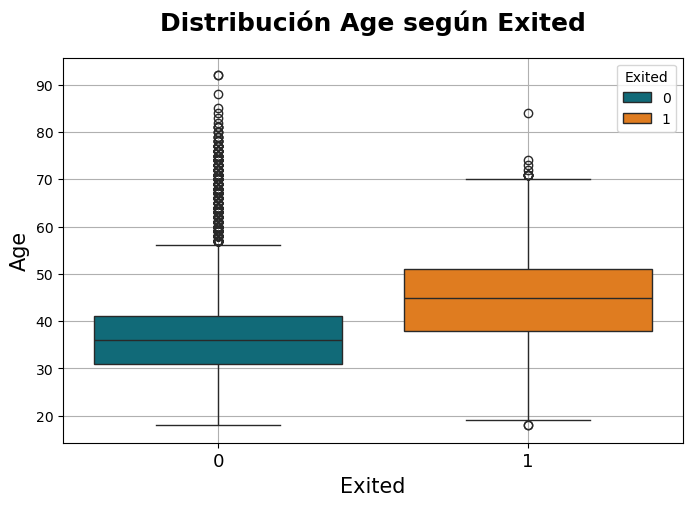

In [33]:
boxplot_edad = boxplot_exited(df=df_clients,
                              ycol='Age',
                              path=IMG_PATH)

In [34]:
df_clients[df_clients['Exited'] == 1]['Age'].describe()

count    2037.000000
mean       44.837997
std         9.761562
min        18.000000
25%        38.000000
50%        45.000000
75%        51.000000
max        84.000000
Name: Age, dtype: float64

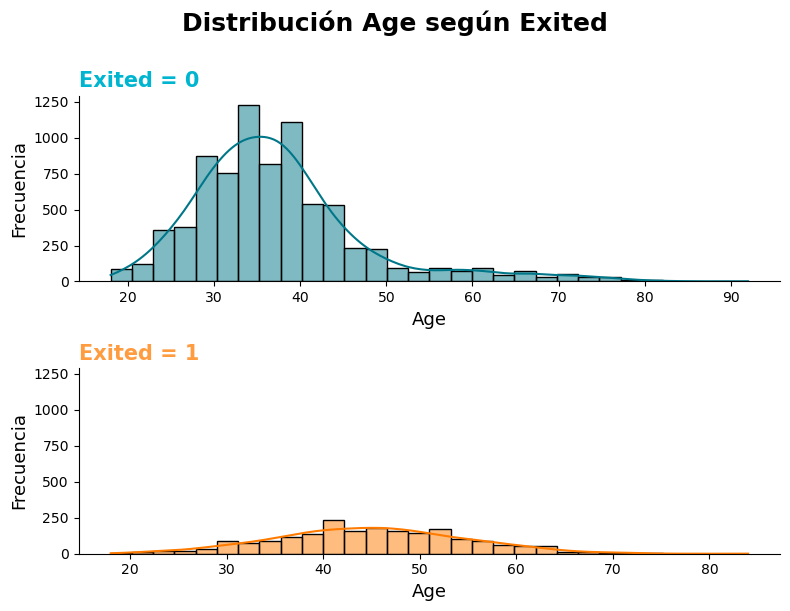

In [35]:
hist_age = histograma_exited(df_clients,
                             xcol='Age',
                             path=IMG_PATH)

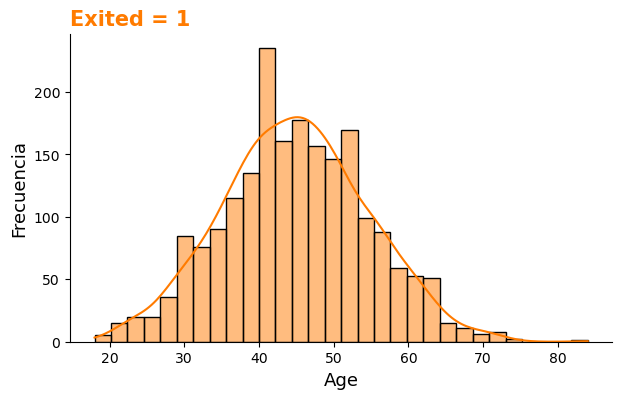

In [36]:
fig, ax = plt.subplots(figsize=(7,4))

sns.histplot(data=df_clients[df_clients['Exited'] == 1], x='Age', bins=30, color=exited_colors[1], kde=True, ax=ax)
ax.set_title("Exited = 1", fontsize=15, fontweight='bold', loc='left', color=NARANJA_3)
ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Frecuencia', fontsize=13)
sns.despine()
plt.show()

### <font color="#8ae6f4">**Observaciones: Edad del cliente**</font>

Se observa una clara concentración de clientes que abandonan entre rangos de 40 y 55 años aproximadamente.
Particularmente, el 50% de los clientes que abandonan tienen una edad entre 38 y 51 años. Lo cual resulta crítico ya que es una edad madura pero aun con capacidad crediticia. Por lo que, para una empresa FinTech, este es un segmento de cliente muy valioso.


### <font color="#ffbf80">**2. Los clientes que abandonan, ¿tienden a ser nuevos o clientes antiguos?**</font>

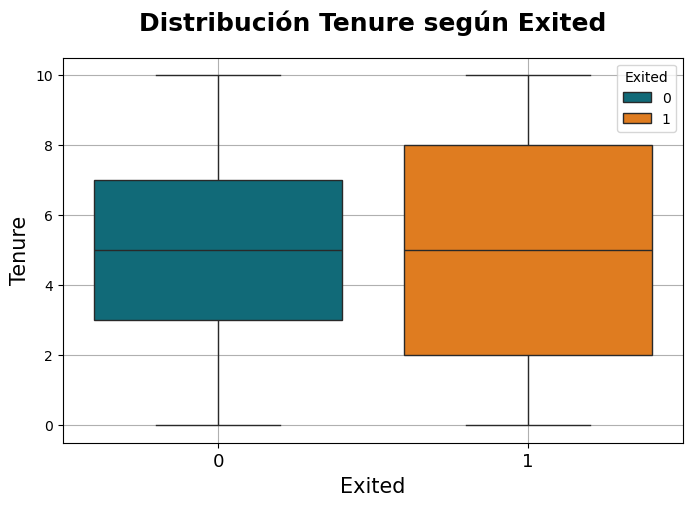

In [37]:
boxplot_edad = boxplot_exited(df=df_clients,
                              ycol='Tenure',
                              path=IMG_PATH)

In [38]:
df_clients.groupby('Exited')['Tenure'].median()

Exited
0    5.0
1    5.0
Name: Tenure, dtype: float64

### <font color="#8ae6f4">**Observaciones: Antigüedad del cliente**</font>

Al observar la distribución de la **angitüedad *(Tenure)*** de los clientes que abandonan en relación a la de aquellos que deciden permanecer en la empresa, surgen algunas problemáticas a considerar por parte de la empresa:

> A pesar de que generalmente la antigüedad suele actuar como protector contra el abandono, es decir, clientes con mayor antigüedad tienden a ser más fieles, en el gráfico generado anteriormente, no solo es posible ver que la mediana es idéntica para ambos grupos (Exited = 1 y Exited 0), sino que el gráfico de aquellos que abandonan es más disperso, lo que conlleva que tanto clientes más nuevos como clientes más antiguos están tomando la decisión de cancelar sus servicios con el banco. Esto merece particular atención ya que, como se mencionó, el comportamiento esperado suele ser el inverso al presente en los datos.

### <font color="#ffbf80">**3. ¿El género está asociado a mayores niveles de Churn?**</font>

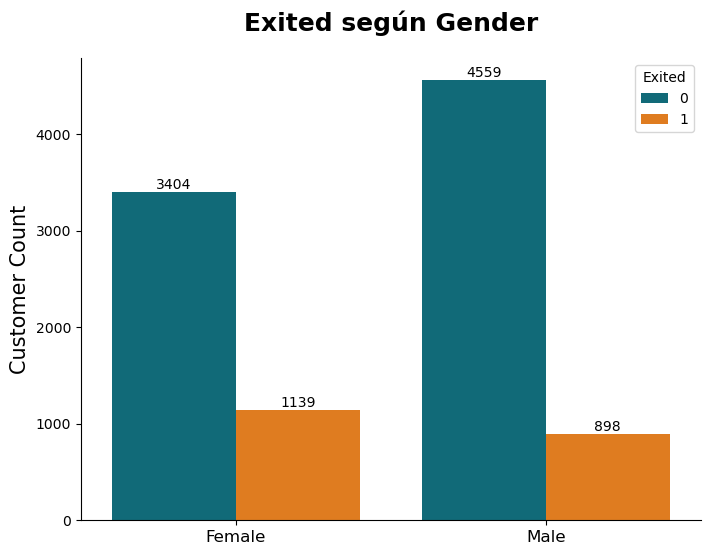

In [39]:
bar_gender = bar_exited(df=df_clients,
                        xcol='Gender',
                        figsize=(8,6),
                        path=IMG_PATH)

In [40]:
gender_counts = pd.DataFrame(df_clients.groupby(['Gender', 'Exited'])['Gender'].value_counts()).reset_index()
gender_counts

,Gender,Exited,count
0,Female,0,3404
1,Female,1,1139
2,Male,0,4559
3,Male,1,898


In [41]:
gender_exit_rate_table = pivot_and_exited_rate(df=gender_counts,
                                              index_col='Gender')
gender_exit_rate_table

,Gender,No Exited,Exited,Exit Rate (%)
0,Female,3404,1139,25.07
1,Male,4559,898,16.46


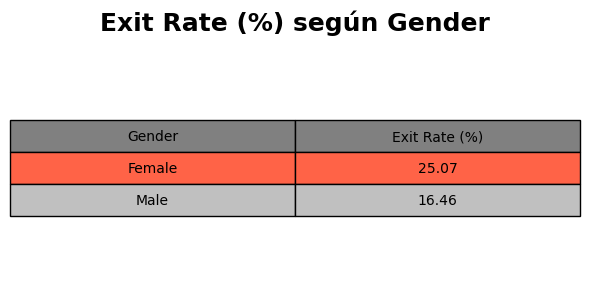

In [42]:
gender_exit_rate_plot = plot_exited_rate_table(df=gender_exit_rate_table,
                                               col='Gender',
                                               path=IMG_PATH)

### <font color="#8ae6f4">**Observaciones: Género**</font>

La tasa de **abandono en mujeres es aproximádamente 9% mayor que en hombres**.

Si bien esto podría ser una simple casualidad, resulta de suma importancia **realizar un análisis exhaustivo para determinar si no existen sesgos en las oportunidades o condiciones por razones de géneros**.

Especialmente en un contexto cultural con una creciente conciencia en igualdad de género, será **necesario entender** cuáles son las razones por las cuales el **25% de nuestras clientas deciden abandonar** la empresa.

Para ello, se recomienda realizar **análisis de satisfacción a través encuestas, análisis de productos y condiciones ofrecidos, y otros aspectos donde se puedan encontrar sesgos.**

### <font color="#ffbf80">**4. ¿Está el puntaje crediticio (Credit Score) asociado al abandono de clientes?**</font>

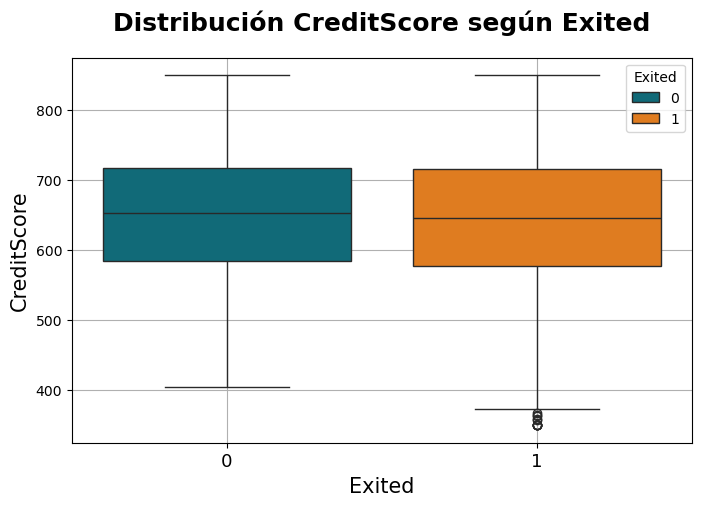

In [43]:
boxplot_edad = boxplot_exited(df=df_clients,
                              ycol='CreditScore',
                              path=IMG_PATH)

### <font color="#8ae6f4">**Observaciones: CreditScore**</font>

Al igual que con la antigüedad del cliente, la distribución del **puntaje crediticio *(Credit Score)*** es similar en ambos grupos, por lo que este factor no parece ser un determinante para predecir el abandono.

### <font color="#ffbf80">**5. ¿Algún país presenta un nivel más alto de abandono?**</font>

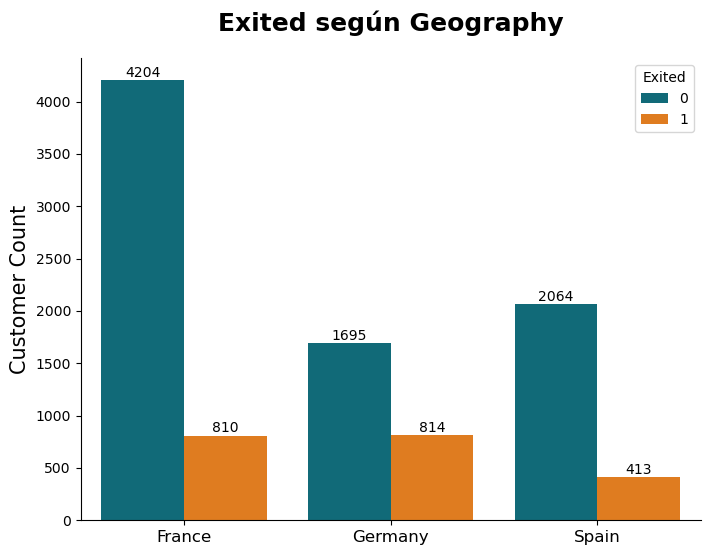

In [44]:
bar_geography = bar_exited(df=df_clients,
                        xcol='Geography',
                        figsize=(8,6),
                        path=IMG_PATH)

In [45]:
geography_counts = pd.DataFrame(df_clients.groupby(['Geography', 'Exited'])['Geography'].value_counts()).reset_index()

In [46]:
geography_exit_rate_table = pivot_and_exited_rate(df=geography_counts,
                                                  index_col='Geography')
geography_exit_rate_table

,Geography,No Exited,Exited,Exit Rate (%)
1,Germany,1695,814,32.44
2,Spain,2064,413,16.67
0,France,4204,810,16.15


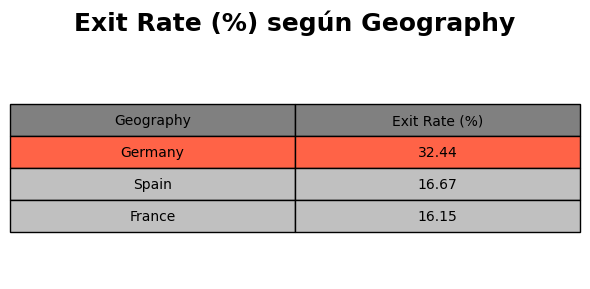

In [47]:
gender_exit_rate_plot = plot_exited_rate_table(df=geography_exit_rate_table,
                                               col='Geography',
                                               path=IMG_PATH)

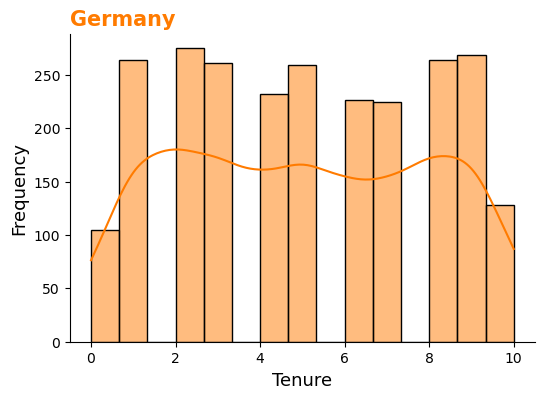

In [48]:
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(data=df_clients[df_clients['Geography'] == 'Germany'], x='Tenure', bins=15, color=exited_colors[1], kde=True, ax=ax)
ax.set_title("Germany", fontsize=15, fontweight='bold', loc='left', color=NARANJA_3)
ax.set_xlabel('Tenure', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
sns.despine()
plt.show()

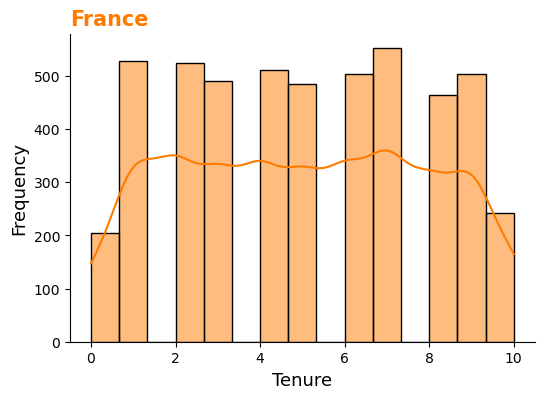

In [49]:
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(data=df_clients[df_clients['Geography'] == 'France'], x='Tenure', bins=15, color=exited_colors[1], kde=True, ax=ax)
ax.set_title("France", fontsize=15, fontweight='bold', loc='left', color=NARANJA_3)
ax.set_xlabel('Tenure', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
sns.despine()
plt.show()

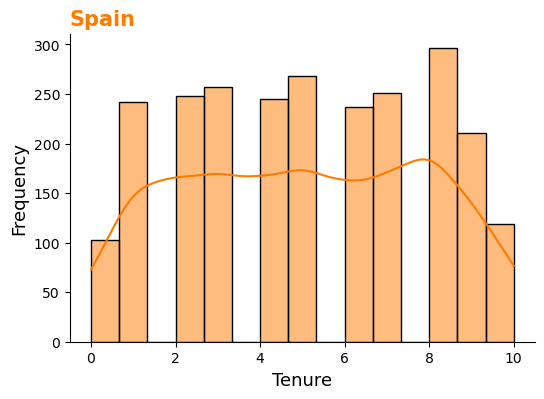

In [50]:
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(data=df_clients[df_clients['Geography'] == 'Spain'], x='Tenure', bins=15, color=exited_colors[1], kde=True, ax=ax)
ax.set_title("Spain", fontsize=15, fontweight='bold', loc='left', color=NARANJA_3)
ax.set_xlabel('Tenure', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
sns.despine()
plt.show()

### <font color="#8ae6f4">**Observaciones: Abandono según País**</font>

Como es posible observar en el gráfico y tabla presentados al inicio de esta sección, **Alemania *(Germany)*** preseta una **tasa de abandono dos veces mayor** que la de los otros dos países donde opera la empresa.

Esto señala un claro descontento por los clientes de dicho país. Para entender un poco más este fenómeno, se investigó si este era un mercado nuevo, quizás en etapas aún experimentales, dado que la cantidad total de clientes en relación a **Francia *(France)*** es bastante menor, pero se observó que **la distribución de la antigüedad de los clientes es similar en todos los países**, lo cual sugiere que **el descontento no es algo reciente, sino más bien un factor constante.**

Esto podría estar relacionado a **factores culturales**, **políticas de la empresa dentro de las regulaciones del país**, u **otro tipo de factores** que requerirán un análisis enfocado sólo en **aspectos del mercado Alemán**.

## <font color='#b23200'>**Conclusiones: Perfil del cliente**</font>

A partir de las exploraciones relacionadas al perfil del cliente, se determinó que los factores que parecen relacionarse más al Churn son:

* **Edad**
  > El 50% de clientes que deciden abandonar la empresa se encuentran en un rango de edad entre 38 y 51 años.
  > Este rango etario podría considerarse óptimo para la adquisición de créditos bancarios, por lo cual este fenómeno requerirá un análisis más profundo para entender las razones por las cuales los clientes deciden abandonar la empresa.
  > Una posible hipótesis podría ser que empresas competidoras ofrezcan mejores condiciones crediticias.

* **Género**
  > La tasa de abandono en mujeres es aproximádamente 9% mayor que en hombres.
  > Será necesario entender si existen razones fundadas detrás de esto, ya que podrían existir sesgos en las ofertas o condiciones de los productos de la empresa en cuanto al género. Esto puede ser un área crítica en un contexto cultural cada vez más consciente en asuntos referentes a la igualdad de género.

* **Geografía**
  > Se descubrió que existen una tasa de abandono significativamente mayor en Alemania. Será necesario hacer un análisis dirigido a las características presentes en este país para poder entender que factores hacen que este país en particular presente una tasa de abandono 2 veces mayor que en los otros dos territorios donde opera la empresa.

## <font color="#ff743d">**Transacciones del cliente**</font>

### <font color="#ffbf80">**6. Los clientes que abandonan, ¿presentan algún comportamiento similar en el volumen de transacciones antes de irse?**</font>

In [51]:
df_tx_exited = df_tx.merge(df_clients[['CustomerId', 'Exited', 'ExitDate']], on='CustomerId')

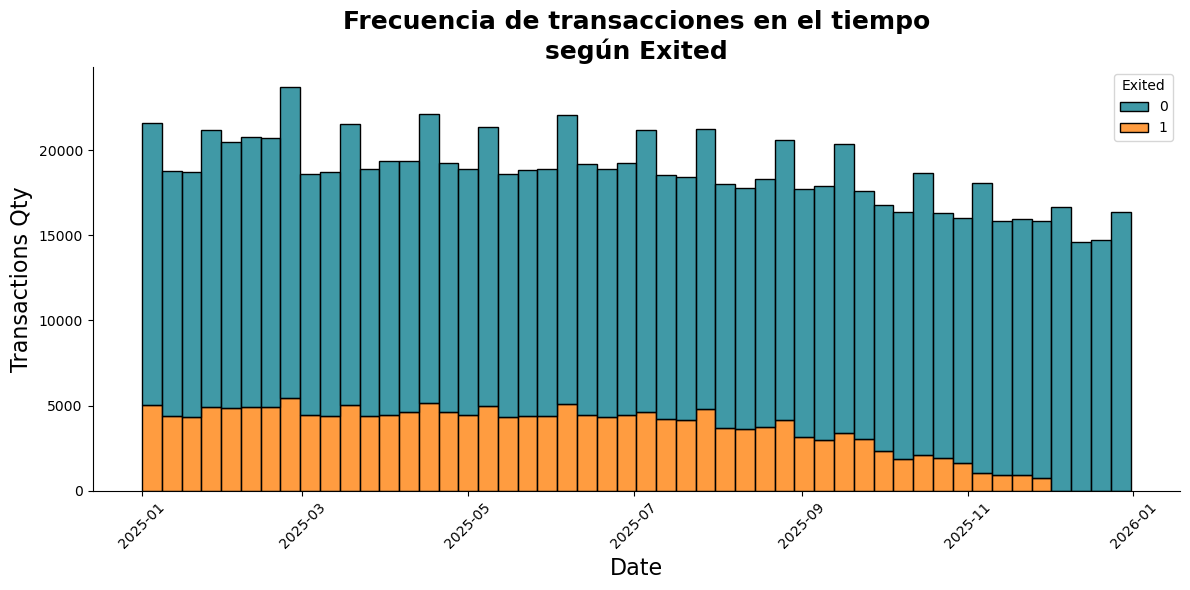

In [52]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=df_tx_exited, 
    x="TransactionDate",
    hue="Exited",
    bins=50,          
    multiple="stack",
    palette=exited_colors
)
plt.title("Frecuencia de transacciones en el tiempo\nsegún Exited", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=16)
plt.ylabel("Transactions Qty", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMG_PATH/'eda_transaction_frequency.png', dpi=300)
sns.despine()
plt.show()

In [53]:
CUTOFF_DATE = df_tx['TransactionDate'].max() - pd.Timedelta(days=90)
WINDOW_DATE = CUTOFF_DATE - pd.Timedelta(days=180)

In [54]:
CUTOFF_DATE

Timestamp('2025-10-02 00:00:00')

In [55]:
churners = df_clients[(df_clients['Exited'] == 1) & (df_clients['ExitDate'] >= CUTOFF_DATE)]
no_churners = df_clients[df_clients['Exited'] == 0].sample(len(churners), random_state=42)

In [56]:
ids_churners = churners['CustomerId'].unique()
ids_no_churners = no_churners['CustomerId'].unique()

In [57]:
len(churners)

1851

In [58]:
ids_sampled = np.concatenate((ids_churners, ids_no_churners))

In [59]:
df_tx_exited_sampled = df_tx_exited[df_tx_exited['CustomerId'].isin(ids_sampled)].copy()

In [60]:
df_tx_exited_sampled = df_tx_exited_sampled[(df_tx_exited_sampled['TransactionDate'] >= WINDOW_DATE) & (df_tx_exited_sampled['TransactionDate'] < CUTOFF_DATE)]

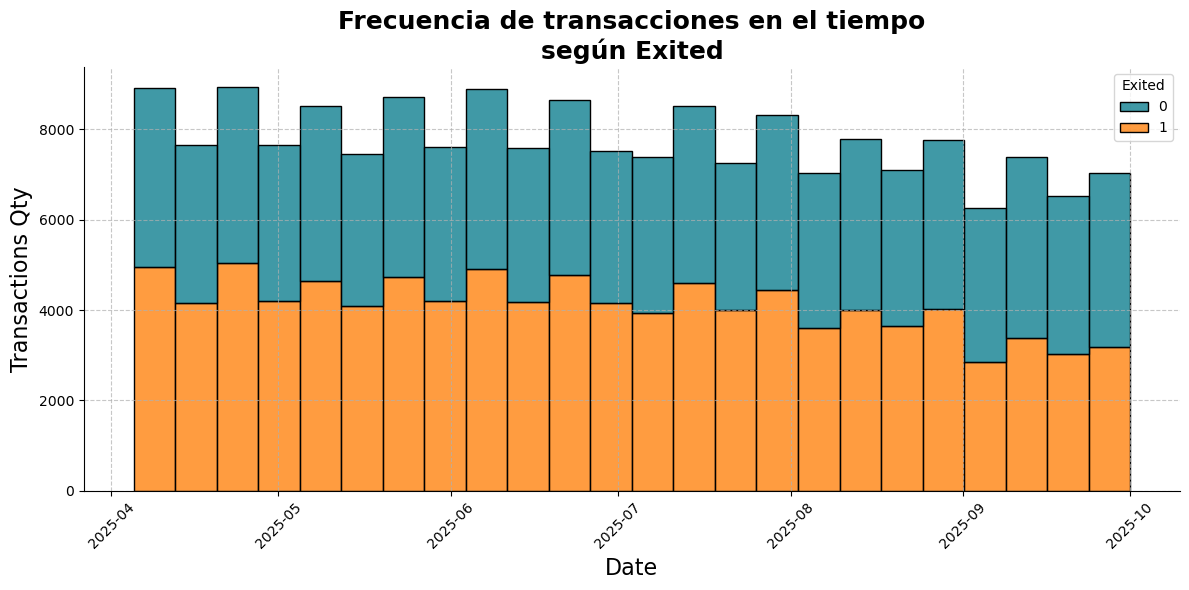

In [61]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=df_tx_exited_sampled, 
    x="TransactionDate",
    hue="Exited",
    bins=24,          
    multiple="stack",
    palette=exited_colors
)
plt.title("Frecuencia de transacciones en el tiempo\nsegún Exited", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=16)
plt.ylabel("Transactions Qty", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMG_PATH/'transaction_frequency_sampled.png', dpi=300)
sns.despine()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### <font color="#8ae6f4">**Observaciones: Volumen de transacciones según Abandono**</font>

In [62]:
CUTOFF_DATE

Timestamp('2025-10-02 00:00:00')

In [63]:
df_tx['TransactionDate'].max()

Timestamp('2025-12-31 00:00:00')

In [64]:
WINDOW_DATE

Timestamp('2025-04-05 00:00:00')

In [65]:
len(churners)

1851

Se puede observar en el primer gráfico que el comportamiento de la cantidad de transacciones disminuye notablemente. Sin embargo, la cantidad de No Churners es considerablemente mayor a la cantidad de Churners, por lo que:

Para evaluar este comportamiento se tomó una muestra de la siguiente manera:
* Se consideraron Churners solo los clientes que abandonaron la empresa entre el **2025-07-02** y el **2025-09-30**
* Se consideró una ventana de observación de 6 meses: entre **2025-01-03** y **2025-07-02**
* Se tomo una muestra de 1837 clientes **No Churners**, para que el volumen de transacciones fuese relativo a la misma cantidad de clientes observados.


Así, si bien el declive en el volumen transaccional es menos pronunciado, es posible observar que mientras el volumen de transacciones de los No Churners (GRIS) se mantiene estable dentro del período observado, el volumen transaccional de los clientes que abandonaron dentro de los tres meses posteriores a `CUTOFF_DATE` disminuye a medida que se acerca dicha fecha.
Esto es un indicador de que, como es de esperarse, la actividad del cliente tiende a disminuir cuando se aproxima un evento de Churn, por lo cual el volumen de transacciones mensual será probablemente un indicador a tener en cuenta.

### <font color="#ffbf80">**7. ¿Difieren los montos de las transacciones de acuerdo a la condición de abandono?**</font>

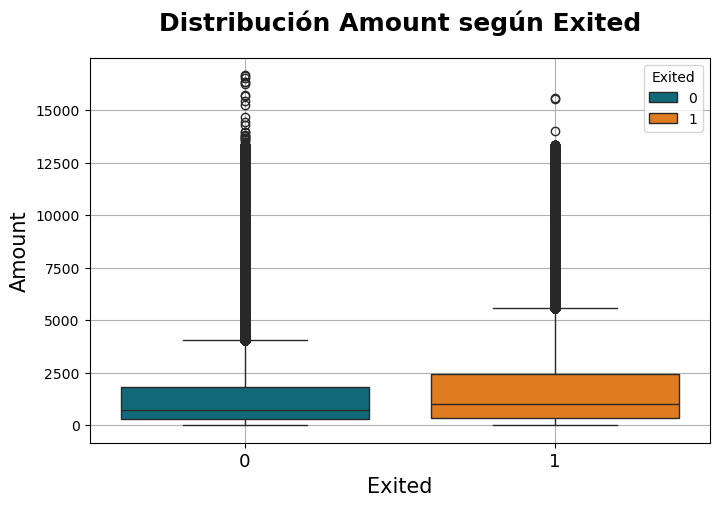

In [66]:
boxplot_tx = boxplot_exited(df=df_tx_exited,
                            ycol='Amount',
                            path=IMG_PATH)

In [67]:
tx_no_churners = df_tx_exited[df_tx_exited['Exited'] == 0]

In [68]:
tx_no_churners.describe()

,TransactionDate,Amount,Exited,ExitDate
count,763511,763511.000000,763511.0,0
mean,2025-07-01 13:06:49.026720256,1416.358967,0.0,NaT
min,2025-01-01 00:00:00,5.000000,0.0,NaT
25%,2025-04-01 00:00:00,290.140000,0.0,NaT
50%,2025-07-01 00:00:00,738.320000,0.0,NaT
75%,2025-10-01 00:00:00,1803.345000,0.0,NaT
max,2025-12-31 00:00:00,16660.780000,0.0,NaT
std,NaN,1869.270053,0.0,NaN


In [69]:
tx_churners = df_tx_exited[df_tx_exited['Exited'] == 1]

In [70]:
tx_churners.describe()

,TransactionDate,Amount,Exited,ExitDate
count,175740,175740.000000,175740.0,175740
mean,2025-05-21 00:24:41.297371392,1832.184522,1.0,2025-11-23 03:19:34.762717696
min,2025-01-01 00:00:00,3.860000,1.0,2025-02-07 00:00:00
25%,2025-03-09 00:00:00,351.445000,1.0,2025-11-05 00:00:00
50%,2025-05-17 00:00:00,993.385000,1.0,2025-11-30 00:00:00
75%,2025-07-27 00:00:00,2441.000000,1.0,2025-12-16 00:00:00
max,2025-11-30 00:00:00,15564.600000,1.0,2025-12-30 00:00:00
std,NaN,2234.590089,0.0,NaN


In [71]:
def label_tx(df):

    iq1 = df['Amount'].quantile(0.25)
    iq3 = df['Amount'].quantile(0.75)
    iqr = iq3 - iq1
    upper_bound = iq3 + (iqr * 1.5)
    lower_bound = iq1 - (iqr * 1.5)

    df['tx_label'] = 'Regular'

    df.loc[(df['Amount'] > upper_bound) | (df['Amount'] < lower_bound), 'tx_label'] = 'Outlier'

    return df

In [72]:
tx_no_churners = label_tx(tx_no_churners)

In [73]:
tx_churners = label_tx(tx_churners)

In [74]:
tx_no_churners_filtered = tx_no_churners[tx_no_churners['tx_label'] == 'Regular']
tx_churners_filtered = tx_churners[tx_churners['tx_label'] == 'Regular']

In [75]:
txs_no_outliers = pd.concat([tx_no_churners_filtered, tx_churners_filtered])

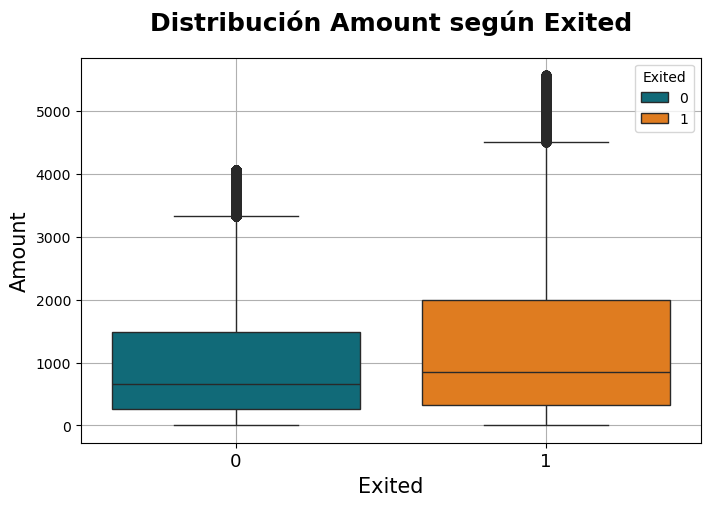

In [76]:
boxplot_tx = boxplot_exited(df=txs_no_outliers,
                            ycol='Amount',
                            path=IMG_PATH)

In [77]:
np.round(tx_churners['Amount'].describe(), 2)

count    175740.00
mean       1832.18
std        2234.59
min           3.86
25%         351.44
50%         993.38
75%        2441.00
max       15564.60
Name: Amount, dtype: float64

In [78]:
np.round(tx_no_churners['Amount'].describe(), 2)

count    763511.00
mean       1416.36
std        1869.27
min           5.00
25%         290.14
50%         738.32
75%        1803.34
max       16660.78
Name: Amount, dtype: float64

### <font color="#8ae6f4">**Observaciones: Monto de transacciones según Abandono**</font>

El análisis de la distribución del monto de las transacciones realizadas en ambos grupos muestra un comportamiento particular que llama la atención:

> El grupo de clientes que abandonan (**`Exited = 1` -> Churners**) muestra una distribución considerablemente más amplia en relación a aquellos que deciden permanecer en la empresa. Esto implica que los clientes que deciden irse son aquellos que mueven mayor cantidad de dinero, es decir, clientes con buen poder adquisitivo, y por lo tanto, clientes de alto interés para el banco.

Para entender mejor este fenómeno, se observará la tasa de abandono correspondiente a cada segmento definidio anteriormente para visualizar y así validar o refutar la hipótesis planteada.

### <font color="#ffbf80">**Extra: Customer Cluster Label**</font>

In [79]:
cluster_label_counts = pd.DataFrame(df_clients.groupby(['CustomerSegment', 'Exited'])['CustomerSegment'].value_counts()).reset_index()

In [80]:
exit_rate_cluster_label = pivot_and_exited_rate(cluster_label_counts,
                                                index_col='CustomerSegment')

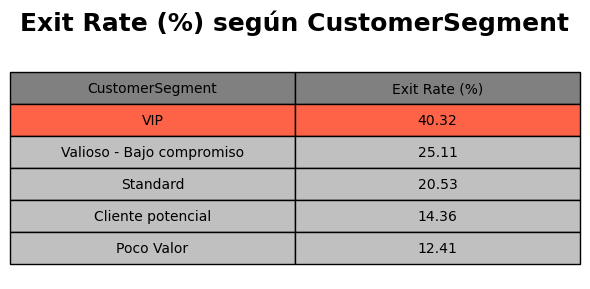

In [81]:
exit_rate_cluster_table = plot_exited_rate_table(df=exit_rate_cluster_label,
                                                 col='CustomerSegment',
                                                 path=IMG_PATH)

In [82]:
exit_rate_cluster_label = exit_rate_cluster_label.sort_values(by='Exit Rate (%)', ascending=False)

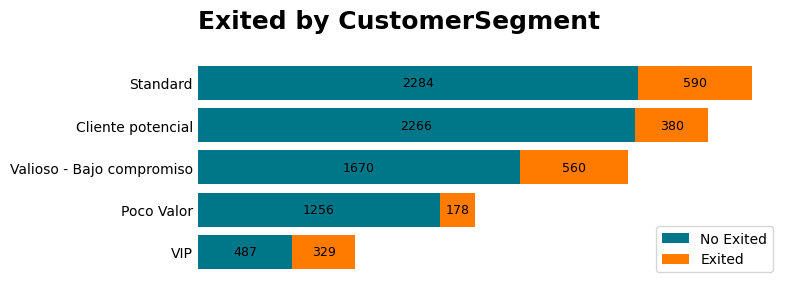

In [83]:
barh_cluster_label = barh_stack_exited(df=exit_rate_cluster_label,
                                       ycol='CustomerSegment',
                                       path=IMG_PATH)

### <font color="#ffbf80">**8. ¿El incremento en operaciones de retiro de dinero (CASHOUT) es un indicador de abandono?**</font>

In [84]:
df_tx_exited_sampled

,TransactionId,CustomerId,TransactionDate,Amount,TransactionType,Exited,ExitDate
260072,1094367,15600174,2025-04-05,488.73,PAYMENT,0,NaT
260073,527947,15670172,2025-04-05,2932.67,CASH_IN,0,NaT
260075,955711,15715047,2025-04-05,956.85,DEBIT,1,2025-12-19
260076,876303,15605826,2025-04-05,2524.70,TRANSFER,1,2025-11-19
260079,1151627,15715709,2025-04-05,745.90,PAYMENT,0,NaT
...,...,...,...,...,...,...,...
736961,1545241,15806796,2025-10-01,429.27,DEBIT,0,NaT
736963,1308264,15754053,2025-10-01,2484.48,CASH_OUT,0,NaT
736971,1026182,15683416,2025-10-01,9902.29,TRANSFER,1,2025-12-06
736972,60335,15581539,2025-10-01,713.37,PAYMENT,0,NaT


In [85]:
df_tx_exited_sampled = df_tx_exited[df_tx_exited['CustomerId'].isin(ids_sampled)].copy()
df_tx_exited_sampled = df_tx_exited_sampled[(df_tx_exited_sampled['TransactionDate'] >= WINDOW_DATE) & (df_tx_exited_sampled['TransactionDate'] < CUTOFF_DATE)]

In [86]:
df_tx_types = pd.DataFrame(df_tx_exited_sampled.groupby(['TransactionDate', 'TransactionType', 'Exited'])['TransactionType'].value_counts()).reset_index()

In [87]:
df_tx_types

,TransactionDate,TransactionType,Exited,count
0,2025-04-05,CASH_IN,0,54
1,2025-04-05,CASH_IN,1,82
2,2025-04-05,CASH_OUT,0,66
3,2025-04-05,CASH_OUT,1,89
4,2025-04-05,DEBIT,0,80
...,...,...,...,...
1795,2025-10-01,DEBIT,1,31
1796,2025-10-01,PAYMENT,0,103
1797,2025-10-01,PAYMENT,1,53
1798,2025-10-01,TRANSFER,0,157


In [88]:
pivot_df_tx_types = df_tx_types.pivot_table(index='TransactionDate', 
                                 columns=['Exited', 'TransactionType'], 
                                 values='count',
                                 fill_value=0)

In [89]:
pivot_df_tx_types

Exited                0                                        1           \
TransactionType CASH_IN CASH_OUT  DEBIT PAYMENT TRANSFER CASH_IN CASH_OUT   
TransactionDate                                                             
2025-04-05         54.0     66.0   80.0   125.0    155.0    82.0     89.0   
2025-04-06         57.0     60.0   92.0   133.0    159.0    64.0     95.0   
2025-04-07         58.0     70.0   83.0   131.0    171.0    84.0     76.0   
2025-04-08         53.0     57.0   91.0   142.0    156.0    74.0     96.0   
2025-04-09         65.0     68.0   93.0   135.0    174.0    64.0     88.0   
...                 ...      ...    ...     ...      ...     ...      ...   
2025-09-27         60.0     56.0   71.0   142.0    164.0    45.0     51.0   
2025-09-28         61.0     74.0   83.0   118.0    133.0    49.0     53.0   
2025-09-29         43.0     57.0  103.0   123.0    153.0    55.0     59.0   
2025-09-30         43.0     58.0   91.0   143.0    174.0    54.0     58.0   
2025-10-01         60.0     66.0   95.0   103.0    157.0    28.0     34.0   

Exited                                  
TransactionType DEBIT PAYMENT TRANSFER  
TransactionDate                         
2025-04-05       83.0   146.0    214.0  
2025-04-06       81.0   144.0    243.0  
2025-04-07       91.0   133.0    234.0  
2025-04-08       90.0   144.0    225.0  
2025-04-09       77.0   148.0    191.0  
...               ...     ...      ...  
2025-09-27       52.0   108.0    175.0  
2025-09-28       49.0   106.0    157.0  
2025-09-29       46.0   107.0    131.0  
2025-09-30       56.0    97.0    152.0  
2025-10-01       31.0    53.0    103.0  

[180 rows x 10 columns]

In [90]:
pivot_df_tx_types.columns = [f'Exited_{exited}_Type_{txtype}' for exited, txtype in pivot_df_tx_types.columns]
pivot_df_tx_types

,Exited_0_Type_CASH_IN,Exited_0_Type_CASH_OUT,Exited_0_Type_DEBIT,Exited_0_Type_PAYMENT,Exited_0_Type_TRANSFER,Exited_1_Type_CASH_IN,Exited_1_Type_CASH_OUT,Exited_1_Type_DEBIT,Exited_1_Type_PAYMENT,Exited_1_Type_TRANSFER
TransactionDate,,,,,,,,,,
2025-04-05,54.0,66.0,80.0,125.0,155.0,82.0,89.0,83.0,146.0,214.0
2025-04-06,57.0,60.0,92.0,133.0,159.0,64.0,95.0,81.0,144.0,243.0
2025-04-07,58.0,70.0,83.0,131.0,171.0,84.0,76.0,91.0,133.0,234.0
2025-04-08,53.0,57.0,91.0,142.0,156.0,74.0,96.0,90.0,144.0,225.0
2025-04-09,65.0,68.0,93.0,135.0,174.0,64.0,88.0,77.0,148.0,191.0
...,...,...,...,...,...,...,...,...,...,...
2025-09-27,60.0,56.0,71.0,142.0,164.0,45.0,51.0,52.0,108.0,175.0
2025-09-28,61.0,74.0,83.0,118.0,133.0,49.0,53.0,49.0,106.0,157.0
2025-09-29,43.0,57.0,103.0,123.0,153.0,55.0,59.0,46.0,107.0,131.0


In [91]:
total_vol_exited_0 = (pivot_df_tx_types['Exited_0_Type_CASH_IN'] + 
                      pivot_df_tx_types['Exited_0_Type_CASH_OUT'] + 
                      pivot_df_tx_types['Exited_0_Type_DEBIT'] + 
                      pivot_df_tx_types['Exited_0_Type_PAYMENT'] + 
                      pivot_df_tx_types['Exited_0_Type_TRANSFER'])

total_vol_exited_1 = (pivot_df_tx_types['Exited_1_Type_CASH_IN'] + 
                      pivot_df_tx_types['Exited_1_Type_CASH_OUT'] + 
                      pivot_df_tx_types['Exited_1_Type_DEBIT'] + 
                      pivot_df_tx_types['Exited_1_Type_PAYMENT'] + 
                      pivot_df_tx_types['Exited_1_Type_TRANSFER'])

pivot_df_tx_types['Ratio_CASHOUT_Exited_0'] = pivot_df_tx_types['Exited_0_Type_CASH_OUT'] / total_vol_exited_0
pivot_df_tx_types['Ratio_CASHOUT_Exited_1'] = pivot_df_tx_types['Exited_1_Type_CASH_OUT'] / total_vol_exited_1

In [92]:
ratio_cashouts = pivot_df_tx_types[['Ratio_CASHOUT_Exited_0','Ratio_CASHOUT_Exited_1']]

In [93]:
ratio_cashouts.head()

,Ratio_CASHOUT_Exited_0,Ratio_CASHOUT_Exited_1
TransactionDate,,
2025-04-05,0.137500,0.144951
2025-04-06,0.119760,0.151515
2025-04-07,0.136452,0.122977
2025-04-08,0.114228,0.152623
2025-04-09,0.127103,0.154930


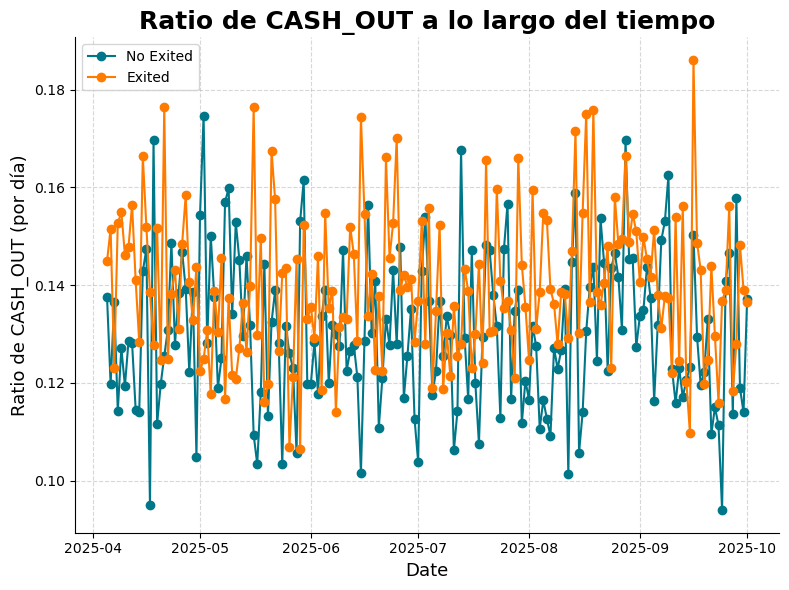

In [94]:
fig, ax = plt.subplots(figsize=(8, 6))

# Exited = 0
ax.plot(ratio_cashouts.index, 
        ratio_cashouts['Ratio_CASHOUT_Exited_0'], 
        marker='o', 
        linestyle='-',
        label='No Exited', 
        color=exited_colors[0])

# Exited = 1
ax.plot(ratio_cashouts.index, 
        ratio_cashouts['Ratio_CASHOUT_Exited_1'], 
        marker='o', 
        linestyle='-',
        label='Exited', 
        color=exited_colors[1])

ax.set_title('Ratio de CASH_OUT a lo largo del tiempo', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Ratio de CASH_OUT (por día)', fontsize=13)

ax.legend()


ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
sns.despine()
plt.savefig(IMG_PATH / 'ratio_cashout_txs.png', dpi=300)
plt.show()

### <font color="#8ae6f4">**Observaciones: Transacciones de retiro (CASH_OUT) según Abandono**</font>

Es posible observar en la **ventana temporal de 6 meses anteriores a la fecha de corte *(CUTOFF DATE)*** que inicialmente, el ratio de retiros de dinero es similar entre ambos grupos, mientras que, a medida que las fechas se acercan al CUTOFF DATE, el grupo naranja (Churners) comienza a tener predominancia sobre la serie azul (No Churners). 
> Esto evidencia un **factor conocido como "Drenaje", donde el cliente comienza a vaciar su cuenta antes de abandonar la empresa.**

## <font color='#b23200'>**Conclusiones: Transacciones del cliente**</font>

* **Decaida de volumen de transacciones**
  > Se observó que los clientes que decidieron abandonar la empresa dentro de los 3 meses a partir de una fecha de corte establecida, mostraron una decaida progresiva en la cantidad de transacciones realizadas dentro de los 6 meses previos a la fecha de corte.
  > Esto sugiere que es necesario monitorear el volumen de transacciones realizadas por un cliente para prevenir el abandono. Podría establecerse el prmedio - una desviación estándar aceptable para generar una alarma sobre el ID del cliente para tomar medidas preventivas si su volumen transaccional cae por debajo de dicho umbral.

* **Clientes VIP abandonan**
  > Gracias a la evaluación del monto de las transacciones de los distintos grupos (Churners y No Churners), se descubrió que dentro de la clusterización realizada en el proceso de consolidación de los datasets, el perfil de cliente que tiene mayor tasa de abandono son los clientes VIP, es decir, clientes con: Alto poder adquisitivo, Alto compromiso, y Alta antigüedad.
  > Esto resulta extremadamente crítico, ya que se observó que el 40% de los clientes más valiosos de la empresa decidieron abandonar. De aquí podría derivarse otra exploración, para entender que monto transaccional neto se ha perdido debido al abandono de dichos clientes.

* **Ratio de retiros de dinero (Cash Out)**
  > Se pudo observar que existe una creciente tendencia a aumentar la cantidad de retiros de dinero en el grupo de clientes que pretende abandonar conforme la fecha de abandono se acerca, fenómeno conocido como "comportamiento de drenaje". Por lo que resultará de suma importancia controlar el ratio de retiros a lo largo del tiempo para cada cliente, con el objetivo de identificarlos con suficiente anticipación para intervenirlos.

## <font color="#ff743d">**Interacciones del cliente con la App**</font>

### <font color="#ffbf80">**10. Los clientes que abandonan, ¿muestran algún patrón particular en la frecuencia de inicio de sesiones?**</font>

In [95]:
df_ss_exited = df_ss.merge(df_clients[['CustomerId', 'Exited', 'ExitDate']], on='CustomerId')

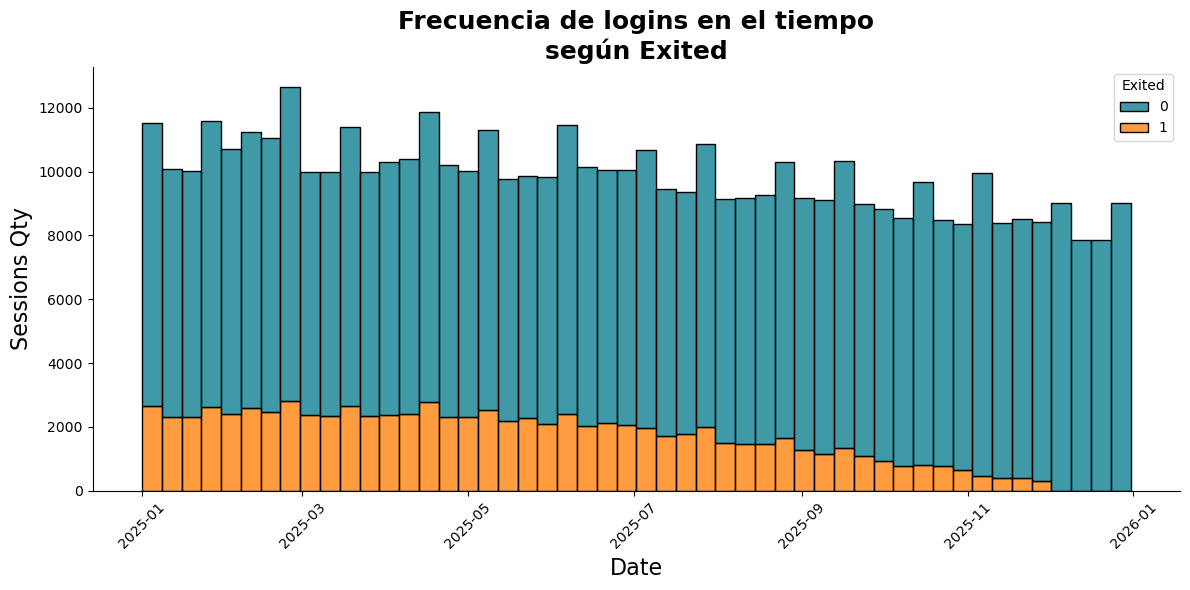

In [96]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=df_ss_exited, 
    x="SessionDate",
    hue="Exited",
    bins=50,          
    multiple="stack",
    palette=exited_colors
)
plt.title("Frecuencia de logins en el tiempo\nsegún Exited", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=16)
plt.ylabel("Sessions Qty", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMG_PATH/'eda_sessions_frequency.png', dpi=300)
sns.despine()
plt.show()

In [97]:
churners = df_clients[(df_clients['Exited'] == 1) & (df_clients['ExitDate'] >= CUTOFF_DATE)]
no_churners = df_clients[df_clients['Exited'] == 0].sample(len(churners), random_state=42)

In [98]:
ids_churners = churners['CustomerId'].unique()
ids_no_churners = no_churners['CustomerId'].unique()

In [99]:
ids_sampled = np.concatenate((ids_churners, ids_no_churners))

In [100]:
df_ss_exited_sampled = df_ss_exited[df_ss_exited['CustomerId'].isin(ids_sampled)].copy()
df_ss_exited_sampled = df_ss_exited_sampled[(df_ss_exited_sampled['SessionDate'] >= WINDOW_DATE) & (df_ss_exited_sampled['SessionDate'] < CUTOFF_DATE)]

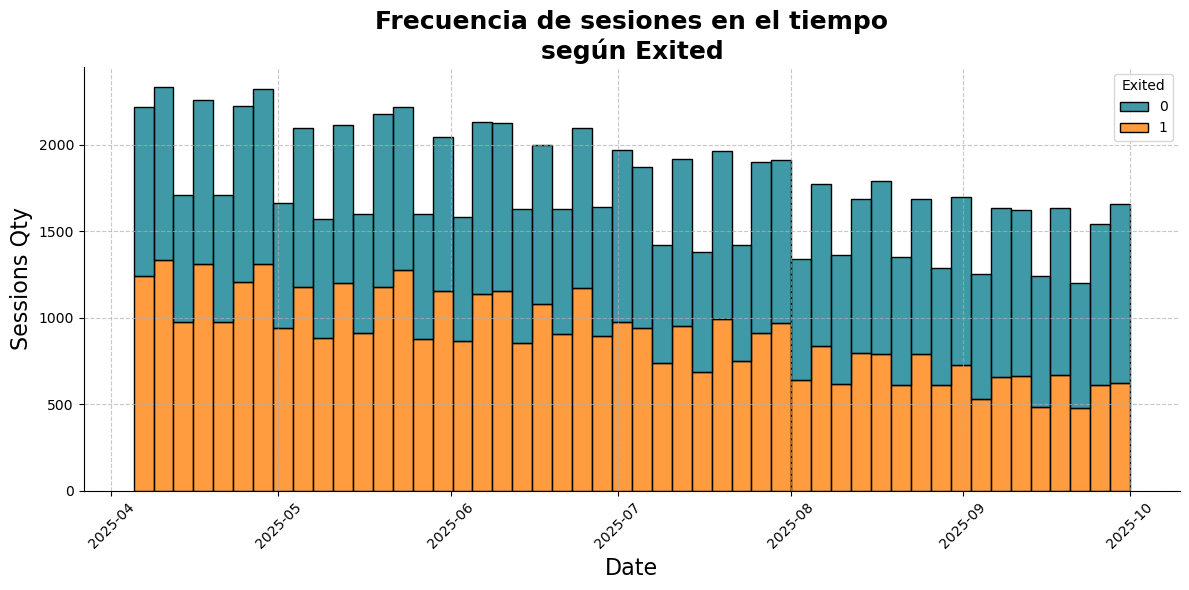

In [101]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=df_ss_exited_sampled, 
    x="SessionDate",
    hue="Exited",
    bins=50,          
    multiple="stack",
    palette=exited_colors
)
plt.title("Frecuencia de sesiones en el tiempo\nsegún Exited", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=16)
plt.ylabel("Sessions Qty", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()

sns.despine()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(IMG_PATH/'sessions_frequency_sampled.png', dpi=300)
plt.show()

In [102]:
df_ss_exited_sampled.sample()

,SessionId,CustomerId,SessionDate,DurationMin,UsedTransfer,UsedPayment,UsedInvest,OpenedPush,FailedLogin,month,Exited,ExitDate
255240,849214,15708504,2025-06-24,7.168309,0,1,0,0,0,2025-06-01,1,2025-10-24


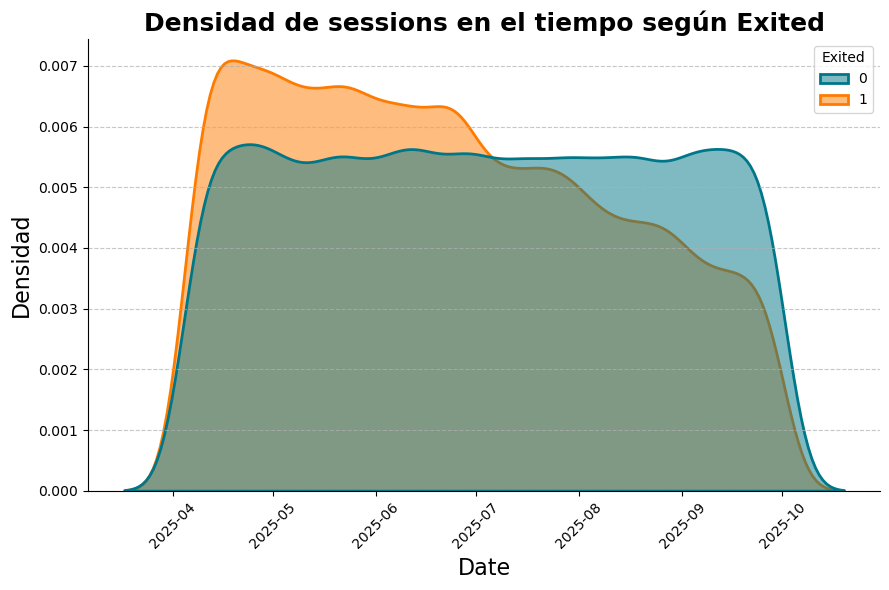

In [103]:
kde_density_ss = kde_density_exited(df=df_ss_exited_sampled,
                                    xcol='SessionDate',
                                    title='sessions',
                                    path=IMG_PATH)

### <font color="#8ae6f4">**Observaciones: Frecuecia de Sesiones según Abandono**</font>

Para medir el volumen de sesiones del cliente, para medir la cantidad de inicios de sessión se tomó, para evaluar dicho comportamiento una muestra de igual manera:

* Se consideraron Churners solo los clientes que abandonaron la empresa entre el **2025-07-02** y el **2025-09-30**
* Se consideró una ventana de observación de 6 meses: entre **2025-01-03** y **2025-07-02**
* Se tomo una muestra de 1842 clientes **No Churners**, para que el volumen de sesiones fuese relativo a la misma cantidad de clientes observados.

A partir de ambos gráficos (barras apiladas y densidad) es posible observar que mientras el volumen de sesiones de los No Churners (GRIS) se mantiene estable dentro del período observado, los clientes que abandonaron dentro de los tres meses posteriores a `CUTOFF_DATE` interactúan cada vez menos con la aplicación de la empresa a medida que se aproxima el evento de Churn.

### <font color="#ffbf80">**11. Los clientes que abandonan, ¿cuentan con mayor cantidad de inicios de sesión fallidos?**</font>

In [104]:
df_ss_exited.sample()

,SessionId,CustomerId,SessionDate,DurationMin,UsedTransfer,UsedPayment,UsedInvest,OpenedPush,FailedLogin,month,Exited,ExitDate
390393,256009,15679249,2025-10-05,18.879702,0,0,0,1,0,2025-10-01,1,2025-12-25


In [105]:
failed_sessions_count = pd.DataFrame(df_ss_exited_sampled.groupby(['month', 'Exited'])['FailedLogin'].value_counts()).reset_index()

In [106]:
failed_sessions_count = failed_sessions_count[failed_sessions_count['month'] < '2025-07-01']

In [107]:
failed_sessions_count

,month,Exited,FailedLogin,count
0,2025-04-01,0,0,6279
1,2025-04-01,0,1,142
2,2025-04-01,1,0,8187
3,2025-04-01,1,1,167
4,2025-05-01,0,0,7117
5,2025-05-01,0,1,143
6,2025-05-01,1,0,9102
7,2025-05-01,1,1,170
8,2025-06-01,0,0,7100
9,2025-06-01,0,1,152


In [108]:
pivot_df = failed_sessions_count.pivot_table(index='month', 
                                 columns=['Exited', 'FailedLogin'], 
                                 values='count',
                                 fill_value=0)

In [109]:
pivot_df

Exited            0              1       
FailedLogin       0      1       0      1
month                                    
2025-04-01   6279.0  142.0  8187.0  167.0
2025-05-01   7117.0  143.0  9102.0  170.0
2025-06-01   7100.0  152.0  8503.0  171.0

In [110]:
pivot_df.columns = [f'Exited_{exited}_Failed_{failed}' for exited, failed in pivot_df.columns]
pivot_df

,Exited_0_Failed_0,Exited_0_Failed_1,Exited_1_Failed_0,Exited_1_Failed_1
month,,,,
2025-04-01,6279.0,142.0,8187.0,167.0
2025-05-01,7117.0,143.0,9102.0,170.0
2025-06-01,7100.0,152.0,8503.0,171.0


In [111]:
pivot_df['Ratio_Failed_Exited_0'] = pivot_df['Exited_0_Failed_1'] / (pivot_df['Exited_0_Failed_0'] + pivot_df['Exited_0_Failed_1'])
pivot_df['Ratio_Failed_Exited_1'] = pivot_df['Exited_1_Failed_1'] / (pivot_df['Exited_1_Failed_0'] + pivot_df['Exited_1_Failed_1'])

In [112]:
pivot_df

,Exited_0_Failed_0,Exited_0_Failed_1,Exited_1_Failed_0,Exited_1_Failed_1,Ratio_Failed_Exited_0,Ratio_Failed_Exited_1
month,,,,,,
2025-04-01,6279.0,142.0,8187.0,167.0,0.022115,0.019990
2025-05-01,7117.0,143.0,9102.0,170.0,0.019697,0.018335
2025-06-01,7100.0,152.0,8503.0,171.0,0.020960,0.019714


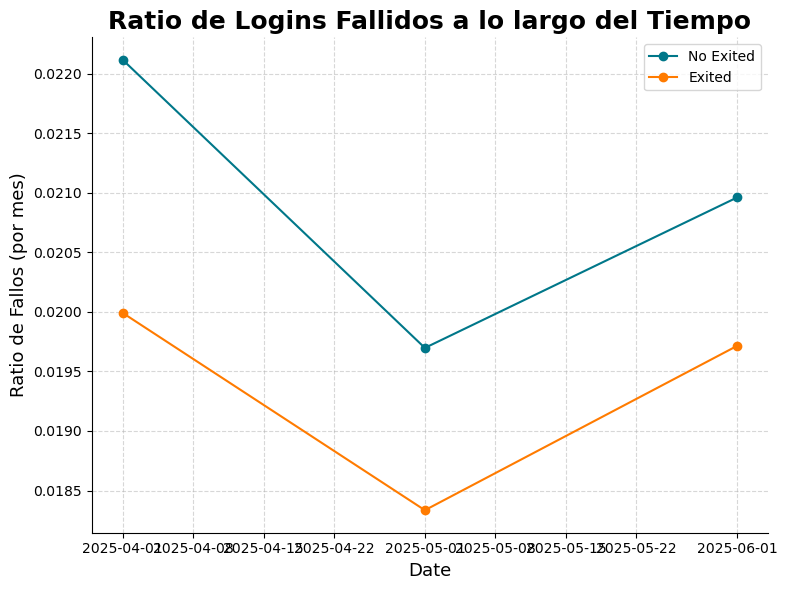

In [113]:
fig, ax = plt.subplots(figsize=(8, 6))

# Exited = 0
ax.plot(pivot_df.index, 
        pivot_df['Ratio_Failed_Exited_0'], 
        marker='o', 
        linestyle='-',
        label='No Exited', 
        color=exited_colors[0])

# Exited = 1
ax.plot(pivot_df.index, 
        pivot_df['Ratio_Failed_Exited_1'], 
        marker='o', 
        linestyle='-',
        label='Exited', 
        color=exited_colors[1])

ax.set_title('Ratio de Logins Fallidos a lo largo del Tiempo', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Ratio de Fallos (por mes)', fontsize=13)

ax.legend()


ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
sns.despine()
plt.savefig(IMG_PATH / 'ratio_failed_logins.png', dpi=300)
plt.show()

In [114]:
df_ss_exited_capped = df_ss_exited[(df_ss_exited['month'] < CUTOFF_DATE) & (df_ss_exited['month'] > WINDOW_DATE)]

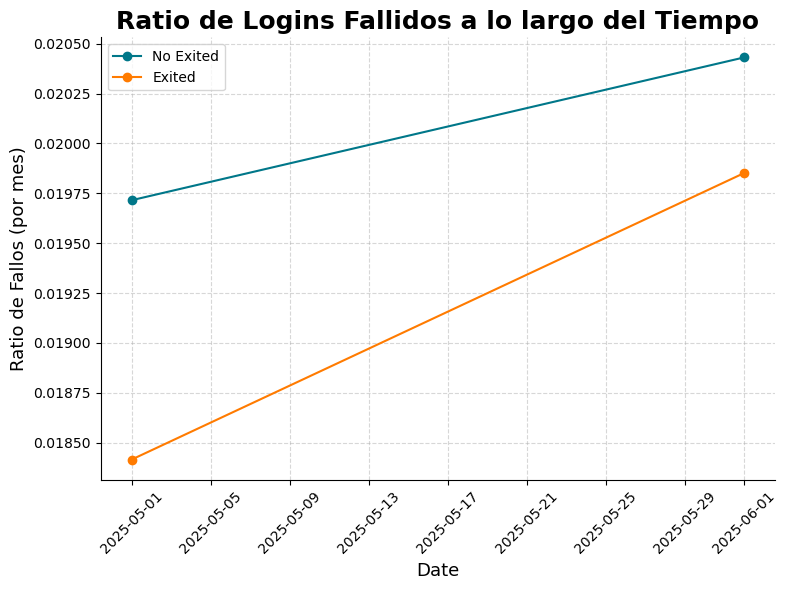

In [115]:
failed_sessions_count = pd.DataFrame(df_ss_exited_capped.groupby(['month', 'Exited'])['FailedLogin'].value_counts()).reset_index()
failed_sessions_count = failed_sessions_count[failed_sessions_count['month'] < '2025-07-01']
pivot_df = failed_sessions_count.pivot_table(index='month', 
                                 columns=['Exited', 'FailedLogin'], 
                                 values='count',
                                 fill_value=0)
pivot_df.columns = [f'Exited_{exited}_Failed_{failed}' for exited, failed in pivot_df.columns]
pivot_df['Ratio_Failed_Exited_0'] = pivot_df['Exited_0_Failed_1'] / (pivot_df['Exited_0_Failed_0'] + pivot_df['Exited_0_Failed_1'])
pivot_df['Ratio_Failed_Exited_1'] = pivot_df['Exited_1_Failed_1'] / (pivot_df['Exited_1_Failed_0'] + pivot_df['Exited_1_Failed_1'])

fig, ax = plt.subplots(figsize=(8, 6))

# Exited = 0
ax.plot(pivot_df.index, 
        pivot_df['Ratio_Failed_Exited_0'], 
        marker='o', 
        linestyle='-',
        label='No Exited', 
        color=exited_colors[0])

# Exited = 1
ax.plot(pivot_df.index, 
        pivot_df['Ratio_Failed_Exited_1'], 
        marker='o', 
        linestyle='-',
        label='Exited', 
        color=exited_colors[1])

ax.set_title('Ratio de Logins Fallidos a lo largo del Tiempo', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Ratio de Fallos (por mes)', fontsize=13)
ax.tick_params(axis='x',rotation=45)

ax.legend()


ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
sns.despine()
plt.savefig(IMG_PATH / 'ratio_failed_logins.png', dpi=300)
plt.show()

### <font color="#8ae6f4">**Observaciones: Ratio de sesiones fallidas según Abandono**</font>

Inicialmente se observó el ratio en la muestra de clientes tomada de la misma manera que para el volumen de inicios de sesiones.
Sin embargo, al utilizar el ratio de sesiones fallidas, es posible tomar la totalidad de clientes dentro de la ventana de tiempo.

De esta manera, es posible observar que en los últimos 2 meses analizados, el aumento de sesiones fallidas para los clientes que decidieron irse dentro de los 3 meses siguientes al `CUTOFF_DATE` aumenta considerablemente, lo cual puede ser un fuerte predictor de Churn.
Una experiencia insatisfactoria con la aplicación puede causar frustración, especialmente en espacios de inversión donde los precios son muy fluctuantes.

Por lo que el ratio de sesiones fallidas se postula como un buen feature para el Feature Engineering

### <font color="#ffbf80">**12. La cantidad de tiempo que un cliente utiliza la app, ¿es un factor asociado al abanodno?**</font>

In [116]:
df_ss_exited_sampled.shape

(88185, 12)

In [117]:
df_ss_exited_sampled['CustomerId'].nunique()

3702

In [118]:
df_ss_exited_sampled.sample()

,SessionId,CustomerId,SessionDate,DurationMin,UsedTransfer,UsedPayment,UsedInvest,OpenedPush,FailedLogin,month,Exited,ExitDate
287374,814596,15570931,2025-07-18,5.779997,0,0,0,0,0,2025-07-01,1,2025-12-25


In [119]:
session_durations = pd.DataFrame(df_ss_exited_sampled.groupby(['month', 'Exited'])['DurationMin'].mean()).reset_index()

In [120]:
session_durations

,month,Exited,DurationMin
0,2025-04-01,0,18.775818
1,2025-04-01,1,21.282054
2,2025-05-01,0,18.866373
3,2025-05-01,1,21.795513
4,2025-06-01,0,18.784117
5,2025-06-01,1,21.319505
6,2025-07-01,0,18.805475
7,2025-07-01,1,21.574964
8,2025-08-01,0,18.708846
9,2025-08-01,1,21.432771


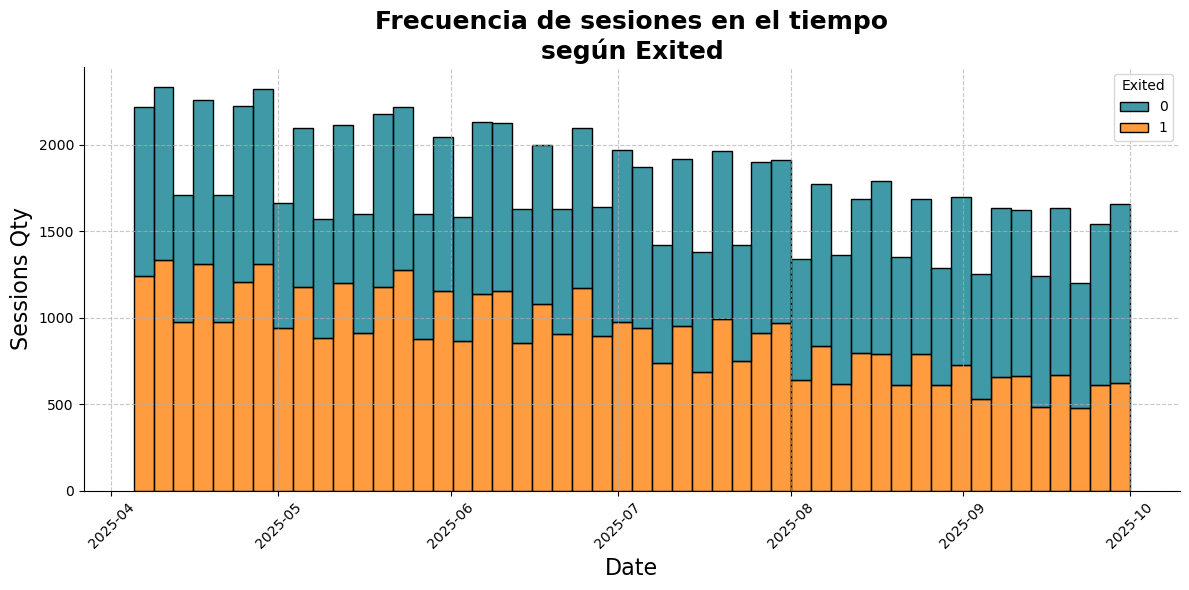

In [121]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=df_ss_exited_sampled, 
    x="SessionDate",
    hue="Exited",
    bins=50,          
    multiple="stack",
    palette=exited_colors
)
plt.title("Frecuencia de sesiones en el tiempo\nsegún Exited", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=16)
plt.ylabel("Sessions Qty", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
sns.despine()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(IMG_PATH/'sessions_frequency_sampled.png', dpi=300)
plt.show()

In [122]:
session_durations_exited_0 = session_durations[session_durations['Exited'] == 0]
session_durations_exited_1 = session_durations[session_durations['Exited'] == 1]

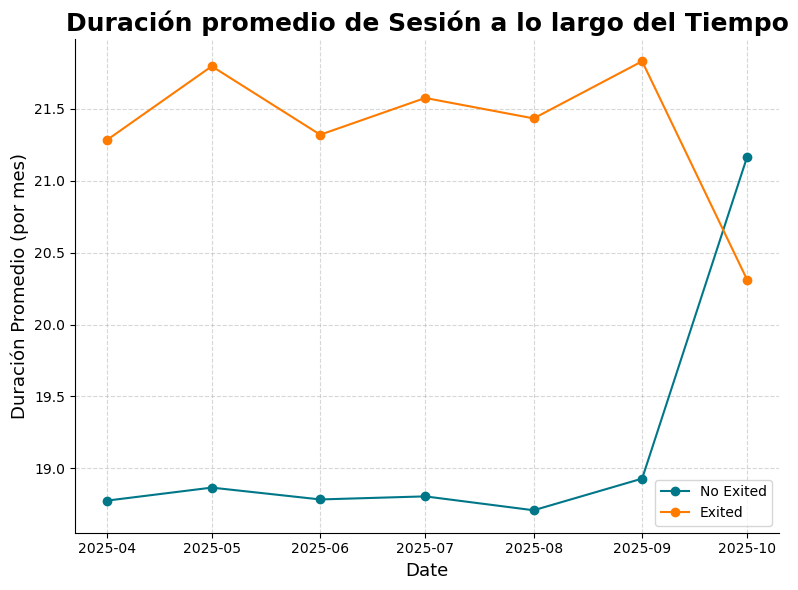

In [123]:
fig, ax = plt.subplots(figsize=(8, 6))

# Exited = 0
ax.plot(session_durations_exited_0['month'], 
        session_durations_exited_0['DurationMin'], 
        marker='o', 
        linestyle='-',
        label='No Exited', 
        color=exited_colors[0])

# Exited = 1
ax.plot(session_durations_exited_1['month'], 
        session_durations_exited_1['DurationMin'], 
        marker='o', 
        linestyle='-',
        label='Exited', 
        color=exited_colors[1])

ax.set_title('Duración promedio de Sesión a lo largo del Tiempo', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Duración Promedio (por mes)', fontsize=13)

ax.legend()


ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
sns.despine()
plt.savefig(IMG_PATH / 'average_sessuion_duration.png', dpi=300)
plt.show()

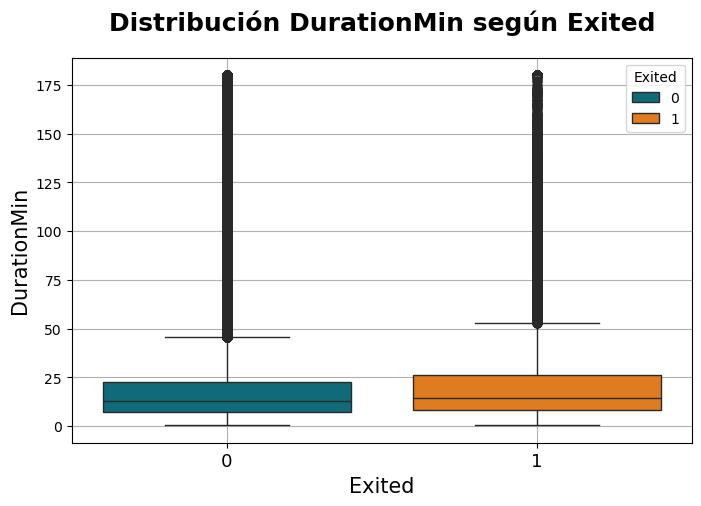

In [124]:
boxplot_ss_duration = boxplot_exited(df=df_ss_exited,
                                     ycol='DurationMin',
                                     path=IMG_PATH)

In [125]:
def label_ss_duration(df):

    iq1 = df['DurationMin'].quantile(0.25)
    iq3 = df['DurationMin'].quantile(0.75)
    iqr = iq3 - iq1
    upper_bound = iq3 + (iqr * 1.5)
    lower_bound = iq1 - (iqr * 1.5)

    df['ss_duration_label'] = 'Regular'

    df.loc[(df['DurationMin'] > upper_bound) | (df['DurationMin'] < lower_bound), 'ss_duration_label'] = 'Outlier'

    return df

In [126]:
df_ss_exited = label_ss_duration(df_ss_exited)
df_ss_exited.head()

,SessionId,CustomerId,SessionDate,DurationMin,UsedTransfer,UsedPayment,UsedInvest,OpenedPush,FailedLogin,month,Exited,ExitDate,ss_duration_label
0,993766,15597739,2025-01-01,13.629286,0,0,0,0,0,2025-01-01,0,NaT,Regular
1,661114,15614834,2025-01-01,31.695885,0,0,0,0,0,2025-01-01,0,NaT,Regular
2,94445,15792328,2025-01-01,6.067959,0,0,0,0,0,2025-01-01,1,2025-10-19,Regular
3,783362,15796413,2025-01-01,88.951831,0,0,0,0,0,2025-01-01,0,NaT,Outlier
4,869314,15630511,2025-01-01,8.622517,1,0,0,0,0,2025-01-01,0,NaT,Regular


In [127]:
df_ss_exited_no_outliers = df_ss_exited[df_ss_exited['ss_duration_label'] == 'Regular']

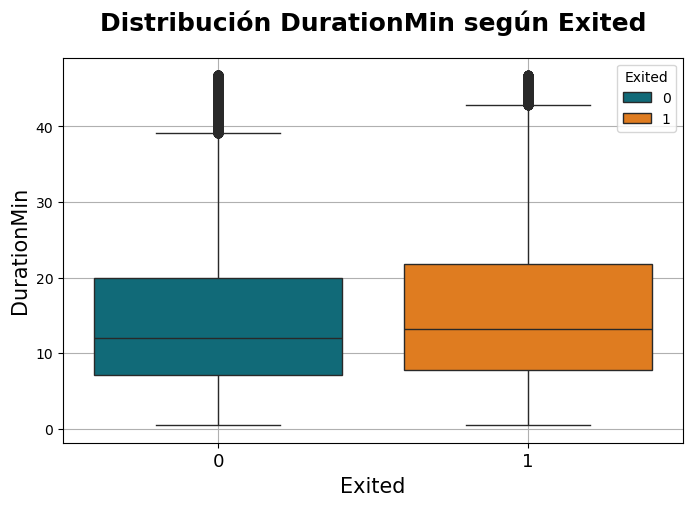

In [128]:
boxplot_ss_duration = boxplot_exited(df=df_ss_exited_no_outliers,
                                     ycol='DurationMin',
                                     path=IMG_PATH)

### <font color="#8ae6f4">**Observaciones: Duración promedio de sesión según Abandono**</font>

Lo que se puede observar a partir de este análisis a simple vista es contraintuitivo, ya que podríamos esperar que aquellos clientes que utilizan la aplicación por mayor tiempo presentan un mayor compromiso con la empresa (debido a mayor actividad).

Sin embargo, esta información es demasiado escasa para asumir algo así. Las sesiones más largas pueden deberse a fallos o alta latencia en la aplicación, lo cual implicaría que el tiempo pase más tiempo conectado sin necesariamente significar mayor compromiso, sino más bien, frustración.

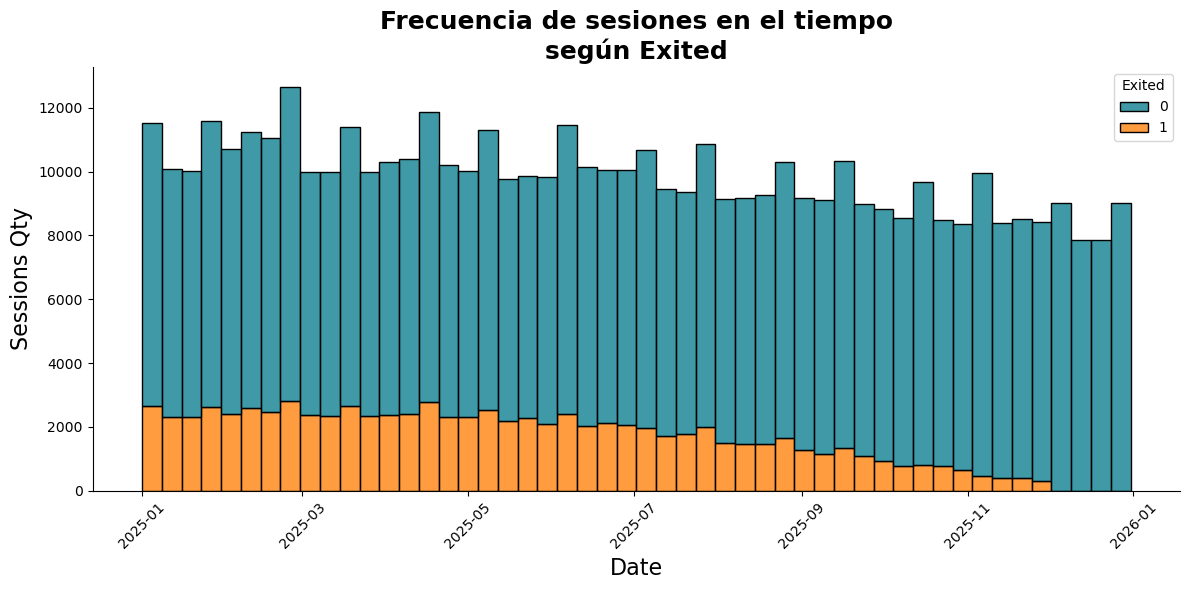

In [129]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=df_ss_exited, 
    x="SessionDate",
    hue="Exited",
    bins=50,          
    multiple="stack",
    palette=exited_colors
)
plt.title("Frecuencia de sesiones en el tiempo\nsegún Exited", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=16)
plt.ylabel("Sessions Qty", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMG_PATH/'eda_sessions_frequency.png', dpi=300)
sns.despine()
plt.show()

## <font color='#b23200'>**Conclusiones: Interacciones del cliente con la App**</font>

A partir de las observaciones en el comportamiento de ambos grupos (*Churners* y *No Churners*) en relación a la interacción con la aplicación, se visualizaron los siguientes aspectos:

* **Frecuencia de sesiones:**
  > Se observó una clara caida en la cantidad de sesiones iniciadas parece ser un fuerte indicador de que el cliente planea abandonar la empresa.
  > Se deberá monitorear el promedio de cada cliente y establecer un umbral que permita alertar si la cantidad habitual de sesiones de un cliente caen por debajo de este para tomar medidas preventivas.

* **Ratio de sesiones fallidas:**
  > Lo que capta la atención de este análisis es que, inicialmente, el ratio de sesiones fallidas en los clientes que permanecen en la empresa es más elevado que el de aquellos que decidieron abandonar. Sin embargo, este último grupo, presenta un pico considerablemente pronunciado en un lapso corto de tiempo.
  > Esto podría indicar que el cliente es más sensible a "la inestabilidad", que al fenómeno de sesiones fallidas en sí mismo.
  > Por lo que resultará primordial entender que es lo que genera dicha inestabilidad en el servicio, y mejorar la experiencia del usuario en relación a la aplicación. Si el presupuesto para esto no es elevado, es posible que buscar una solución media pero más estable, resulte mejor que una potente pero inestable.

* **Duración promedio de sesiones:**
  > Este análisis arrojó inicialmente algo que parece contradictorio: Los clientes que deciden irse son los que pasan mayor tiempo en la aplicación.
  > Sin embargo, esto podría reforzar lo planteado anteriormente, y ser a causa de problemas en el funcionamiento de la aplicación.

# <font color="#6e8ebc">**Feature Engineering**</font>

## <font color="#ff743d">**Datasets Integration**</font>

In [130]:
df_tx['TransactionDate'].max(), df_ss['SessionDate'].max()

(Timestamp('2025-12-31 00:00:00'), Timestamp('2025-12-31 00:00:00'))

A partir de los descubrimientos de la etapa de **Exploratory Data Analysis**, se buscará crear features para llevar las series temporales a un formato tabular y que de esta manera permitan captar patrones para predecir el Churn de clientes.

Para esto, se tomará un período de tiempo de análisis de 1 año, en busca de predecir el **Churn** dentro de los últimos **3 meses *(Ventana de Churn)***. Utilizando la fecha de corte previamente definida:

* `CUTOFF_DATE = '2025-10-02'` hasta `'2025-12-31'`-> Ventana de Churn (Ventana Objetivo)

Luego, se buscará analizar el comportamiento del cliente en distintas ventanas de tiempo con el objetivo de generar indicadores que permitan prevenir de forma temprana la probabilidad de abandono y poder tomar acciones preventivas.

* `WINDOW_1_START = 2024-12-31'`
* `WINDOW_1_END = '2025-04-05'`
* `WINDOW_2_START = '2025-04-05'`
* `WINDOW_2_END = '2025-07-04'`
* `WINDOW_3_START = '2025-07-04'`
* `WINDOW_3_END = CUTOFF_DATE`

### **Nota:**

Siempre se tomará:

* Inicio de fechas: `Periodo a observar >= Fecha Inicio`
* Final de fechas: `Periodo a observar < Fecha Fin`

In [131]:
WINDOW_1_START = CUTOFF_DATE - pd.Timedelta(days=275)
WINDOW_1_START

Timestamp('2024-12-31 00:00:00')

In [132]:
WINDOW_1_END = CUTOFF_DATE - pd.Timedelta(days=180)
WINDOW_1_END

Timestamp('2025-04-05 00:00:00')

In [133]:
WINDOW_2_START = WINDOW_1_END

In [134]:
WINDOW_2_END = CUTOFF_DATE - pd.Timedelta(days=90)
WINDOW_2_END

Timestamp('2025-07-04 00:00:00')

In [135]:
WINDOW_3_START = WINDOW_2_END

### <font color="#ffbf80">**Transactions**</font>

In [136]:
df_tx_filtered = df_tx[(df_tx['TransactionDate'] >= WINDOW_1_START) & (df_tx['TransactionDate'] < CUTOFF_DATE)]

In [137]:
# Crea un DataFrame para los features
features_tx = df_tx_filtered.groupby('CustomerId').agg(
    avg_tx_amount=('Amount', 'mean'),
    std_tx_amount=('Amount', 'std'),
    total_tx=('Amount', 'count'),
    last_tx_date=('TransactionDate', 'max')
).reset_index()

In [138]:
features_tx

,CustomerId,avg_tx_amount,std_tx_amount,total_tx,last_tx_date
0,15565701,991.719104,662.380280,67,2025-09-30
1,15565706,361.451538,294.787766,26,2025-09-08
2,15565714,610.122308,463.329802,91,2025-09-30
3,15565779,2462.528814,2039.060944,59,2025-09-21
4,15565796,594.326170,420.038166,94,2025-09-29
...,...,...,...,...,...
9945,15815628,867.921833,707.187897,60,2025-09-28
9946,15815645,4932.799915,3099.039873,118,2025-09-30
9947,15815656,5375.038287,3351.520896,181,2025-09-30
9948,15815660,656.488929,526.274174,56,2025-09-22


In [139]:
features_tx['days_since_last_tx'] = (CUTOFF_DATE - features_tx['last_tx_date']).dt.days

In [140]:
txs_q1 = df_tx_filtered[(df_tx_filtered['TransactionDate'] >= WINDOW_1_START) & (df_tx_filtered['TransactionDate'] < WINDOW_1_END)]
txs_q2 = df_tx_filtered[(df_tx_filtered['TransactionDate'] >= WINDOW_2_START) & (df_tx_filtered['TransactionDate'] < WINDOW_2_END)]
txs_q3 = df_tx_filtered[(df_tx_filtered['TransactionDate'] >= WINDOW_3_START) & (df_tx_filtered['TransactionDate'] < CUTOFF_DATE)]

In [141]:
total_tx_q1 = txs_q1.groupby('CustomerId').size().reset_index(name='total_tx_q1')
total_tx_q2 = txs_q2.groupby('CustomerId').size().reset_index(name='total_tx_q2')
total_tx_q3 = txs_q3.groupby('CustomerId').size().reset_index(name='total_tx_q3')

In [142]:
features_tx = features_tx.merge(total_tx_q1, on='CustomerId', how='left')
features_tx = features_tx.merge(total_tx_q2, on='CustomerId', how='left')
features_tx = features_tx.merge(total_tx_q3, on='CustomerId', how='left')

total_tx_cols = ['total_tx_q1', 'total_tx_q2', 'total_tx_q3']
features_tx[total_tx_cols] = features_tx[total_tx_cols].fillna(0)

In [143]:
features_tx

,CustomerId,avg_tx_amount,std_tx_amount,total_tx,last_tx_date,days_since_last_tx,total_tx_q1,total_tx_q2,total_tx_q3
0,15565701,991.719104,662.380280,67,2025-09-30,2,25.0,21.0,21.0
1,15565706,361.451538,294.787766,26,2025-09-08,24,14.0,6.0,6.0
2,15565714,610.122308,463.329802,91,2025-09-30,2,32.0,24.0,35.0
3,15565779,2462.528814,2039.060944,59,2025-09-21,11,21.0,14.0,24.0
4,15565796,594.326170,420.038166,94,2025-09-29,3,30.0,31.0,33.0
...,...,...,...,...,...,...,...,...,...
9945,15815628,867.921833,707.187897,60,2025-09-28,4,27.0,15.0,18.0
9946,15815645,4932.799915,3099.039873,118,2025-09-30,2,20.0,43.0,55.0
9947,15815656,5375.038287,3351.520896,181,2025-09-30,2,66.0,49.0,66.0
9948,15815660,656.488929,526.274174,56,2025-09-22,10,15.0,17.0,24.0


In [144]:
df_clients['CustomerId'].nunique()

10000

In [145]:
uniques = features_tx['CustomerId'].unique()

In [146]:
features_tx['tx_q1q2_rate_of_change'] = (features_tx['total_tx_q2'] - features_tx['total_tx_q1']) / (features_tx['total_tx_q1'] + 1)
features_tx['tx_q2q3_rate_of_change'] = (features_tx['total_tx_q3'] - features_tx['total_tx_q2']) / (features_tx['total_tx_q2'] + 1)

In [147]:
features_tx

,CustomerId,avg_tx_amount,std_tx_amount,total_tx,last_tx_date,days_since_last_tx,total_tx_q1,total_tx_q2,total_tx_q3,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change
0,15565701,991.719104,662.380280,67,2025-09-30,2,25.0,21.0,21.0,-0.153846,0.000000
1,15565706,361.451538,294.787766,26,2025-09-08,24,14.0,6.0,6.0,-0.533333,0.000000
2,15565714,610.122308,463.329802,91,2025-09-30,2,32.0,24.0,35.0,-0.242424,0.440000
3,15565779,2462.528814,2039.060944,59,2025-09-21,11,21.0,14.0,24.0,-0.318182,0.666667
4,15565796,594.326170,420.038166,94,2025-09-29,3,30.0,31.0,33.0,0.032258,0.062500
...,...,...,...,...,...,...,...,...,...,...,...
9945,15815628,867.921833,707.187897,60,2025-09-28,4,27.0,15.0,18.0,-0.428571,0.187500
9946,15815645,4932.799915,3099.039873,118,2025-09-30,2,20.0,43.0,55.0,1.095238,0.272727
9947,15815656,5375.038287,3351.520896,181,2025-09-30,2,66.0,49.0,66.0,-0.253731,0.340000
9948,15815660,656.488929,526.274174,56,2025-09-22,10,15.0,17.0,24.0,0.125000,0.388889


In [148]:
features_tx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9950 entries, 0 to 9949
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CustomerId              9950 non-null   object        
 1   avg_tx_amount           9950 non-null   float64       
 2   std_tx_amount           9950 non-null   float64       
 3   total_tx                9950 non-null   int64         
 4   last_tx_date            9950 non-null   datetime64[ns]
 5   days_since_last_tx      9950 non-null   int64         
 6   total_tx_q1             9950 non-null   float64       
 7   total_tx_q2             9950 non-null   float64       
 8   total_tx_q3             9950 non-null   float64       
 9   tx_q1q2_rate_of_change  9950 non-null   float64       
 10  tx_q2q3_rate_of_change  9950 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(2), object(1)
memory usage: 855.2+ KB


In [149]:
features_tx[features_tx['std_tx_amount'].isna()]

,CustomerId,avg_tx_amount,std_tx_amount,total_tx,last_tx_date,days_since_last_tx,total_tx_q1,total_tx_q2,total_tx_q3,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change


In [150]:
features_tx['std_tx_amount'] = features_tx['std_tx_amount'].fillna(0)

In [151]:
(features_tx['total_tx_q3'] == 0).sum()

55

In [152]:
df_clients_filtered = df_clients[df_clients['CustomerId'].isin(uniques)].copy()

In [153]:
consolidated_ds = df_clients_filtered.merge(features_tx, on='CustomerId')

In [154]:
consolidated_ds

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ExitDate,CustomerSegment,avg_tx_amount,std_tx_amount,total_tx,last_tx_date,days_since_last_tx,total_tx_q1,total_tx_q2,total_tx_q3,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2025-11-15,Cliente potencial,1156.498684,912.280129,38,2025-09-29,3,10.0,16.0,12.0,0.545455,-0.235294
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NaT,Standard,828.158710,601.648795,93,2025-09-28,4,36.0,38.0,19.0,0.054054,-0.487179
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2025-12-28,VIP,3295.069068,2027.631067,161,2025-09-28,4,60.0,57.0,44.0,-0.049180,-0.224138
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaT,Poco Valor,410.788571,362.520807,28,2025-09-25,7,9.0,5.0,14.0,-0.400000,1.500000
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NaT,Standard,533.955301,407.263553,83,2025-09-30,2,18.0,32.0,33.0,0.736842,0.030303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9945,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0,NaT,Cliente potencial,1031.317358,912.197459,53,2025-10-01,1,24.0,14.0,15.0,-0.400000,0.066667
9946,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,NaT,Valioso - Bajo compromiso,1121.523571,685.063323,70,2025-09-23,9,26.0,27.0,17.0,0.037037,-0.357143
9947,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1,2025-12-18,Poco Valor,165.247692,89.633522,26,2025-09-24,8,11.0,8.0,7.0,-0.250000,-0.111111
9948,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2025-11-28,Standard,745.372658,513.339716,79,2025-09-29,3,34.0,27.0,18.0,-0.200000,-0.321429


### <font color="#ffbf80">**App Interaction**</font>

In [155]:
df_ss_filtered = df_ss[(df_ss['SessionDate'] >= WINDOW_1_START) & (df_ss['SessionDate'] < CUTOFF_DATE)]

In [156]:
# Crea un DataFrame para los features
features_ss = df_ss_filtered.groupby('CustomerId').agg(
    avg_ss_duration=('DurationMin', 'mean'),
    std_ss_duration=('DurationMin', 'std'),
    total_ss=('DurationMin', 'count'),
    last_ss_date=('SessionDate', 'max')
).reset_index()

In [157]:
features_ss['days_since_last_ss'] = (CUTOFF_DATE - features_ss['last_ss_date']).dt.days

In [158]:
ss_q1 = df_ss_filtered[(df_ss_filtered['SessionDate'] >= WINDOW_1_START) & (df_ss_filtered['SessionDate'] < WINDOW_1_END)]
ss_q2 = df_ss_filtered[(df_ss_filtered['SessionDate'] >= WINDOW_2_START) & (df_ss_filtered['SessionDate'] < WINDOW_2_END)]
ss_q3 = df_ss_filtered[(df_ss_filtered['SessionDate'] >= WINDOW_3_START) & (df_ss_filtered['SessionDate'] < CUTOFF_DATE)]


total_ss_q1 = ss_q1.groupby('CustomerId').size().reset_index(name='total_ss_q1')
total_ss_q2 = ss_q2.groupby('CustomerId').size().reset_index(name='total_ss_q2')
total_ss_q3 = ss_q3.groupby('CustomerId').size().reset_index(name='total_ss_q3')

total_failed_ss_q1 = ss_q1.groupby('CustomerId')['FailedLogin'].sum().reset_index(name='total_failed_ss_q1')
total_failed_ss_q2 = ss_q2.groupby('CustomerId')['FailedLogin'].sum().reset_index(name='total_failed_ss_q2')
total_failed_ss_q3 = ss_q3.groupby('CustomerId')['FailedLogin'].sum().reset_index(name='total_failed_ss_q3')

In [159]:
features_ss

,CustomerId,avg_ss_duration,std_ss_duration,total_ss,last_ss_date,days_since_last_ss
0,15565701,17.521779,11.981571,40,2025-10-01,1
1,15565706,8.590071,3.511256,15,2025-08-30,33
2,15565714,22.611267,24.386485,30,2025-09-26,6
3,15565779,12.386283,8.512453,36,2025-10-01,1
4,15565796,22.752139,22.535810,36,2025-05-28,127
...,...,...,...,...,...,...
9944,15815628,14.845579,9.161912,30,2025-09-13,19
9945,15815645,31.476822,32.357347,102,2025-09-30,2
9946,15815656,27.949345,21.946549,102,2025-09-30,2
9947,15815660,13.303270,7.567265,20,2025-09-10,22


In [160]:
features_ss = features_ss.merge(total_ss_q1, on='CustomerId')
features_ss = features_ss.merge(total_ss_q2, on='CustomerId')
features_ss = features_ss.merge(total_ss_q3, on='CustomerId')
features_ss = features_ss.merge(total_failed_ss_q1, on='CustomerId')
features_ss = features_ss.merge(total_failed_ss_q2, on='CustomerId')
features_ss = features_ss.merge(total_failed_ss_q3, on='CustomerId')

In [161]:
features_ss

,CustomerId,avg_ss_duration,std_ss_duration,total_ss,last_ss_date,days_since_last_ss,total_ss_q1,total_ss_q2,total_ss_q3,total_failed_ss_q1,total_failed_ss_q2,total_failed_ss_q3
0,15565701,17.521779,11.981571,40,2025-10-01,1,13,16,11,1,0,0
1,15565706,8.590071,3.511256,15,2025-08-30,33,8,4,3,0,0,0
2,15565714,22.611267,24.386485,30,2025-09-26,6,6,14,10,0,2,0
3,15565779,12.386283,8.512453,36,2025-10-01,1,9,13,14,0,0,0
4,15565806,13.111484,9.869697,41,2025-09-28,4,9,13,19,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9689,15815628,14.845579,9.161912,30,2025-09-13,19,7,17,6,0,0,0
9690,15815645,31.476822,32.357347,102,2025-09-30,2,30,36,36,0,1,0
9691,15815656,27.949345,21.946549,102,2025-09-30,2,35,36,31,0,0,0
9692,15815660,13.303270,7.567265,20,2025-09-10,22,11,6,3,0,0,0


In [162]:
def calculate_change_rate(row, previous_q, followed_q):
    freq_past = row[previous_q]
    freq_last = row[followed_q]
    
    if freq_past == 0:
        if freq_last > 0:
            return 1.0 
        else:
            return 0.0
    else:
        return (freq_last - freq_past) / freq_past

In [163]:
features_ss['ss_q1q2_rate_of_change'] = features_ss.apply(
                                            lambda row: calculate_change_rate(row, 'total_ss_q1', 'total_ss_q2'), 
                                            axis=1)

features_ss['ss_q2q3_rate_of_change'] = features_ss.apply(
                                            lambda row: calculate_change_rate(row, 'total_ss_q2', 'total_ss_q3'), 
                                            axis=1)

In [164]:
def safe_division(numerator, denominator):
    return numerator / denominator if denominator > 0 else 0.0

features_ss['failed_ratio_q1'] = features_ss.apply(
    lambda row: safe_division(row['total_failed_ss_q1'], row['total_ss_q1']), axis=1
)
features_ss['failed_ratio_q2'] = features_ss.apply(
    lambda row: safe_division(row['total_failed_ss_q2'], row['total_ss_q2']), axis=1
)
features_ss['failed_ratio_q3'] = features_ss.apply(
    lambda row: safe_division(row['total_failed_ss_q3'], row['total_ss_q3']), axis=1
)

In [165]:
# Diferencia entre el ratio del último período y el anterior
features_ss['failed_ratio_spike_q2'] = features_ss['failed_ratio_q2'] - features_ss['failed_ratio_q1']
features_ss['failed_ratio_spike_q3'] = features_ss['failed_ratio_q3'] - features_ss['failed_ratio_q2']

In [166]:
# Selecciona las columnas de ratio
ratio_cols = ['failed_ratio_q1', 'failed_ratio_q2', 'failed_ratio_q3']

# Calcula la desviación estándar para cada fila (axis=1)
features_ss['failed_ratio_volatility'] = features_ss[ratio_cols].std(axis=1)

In [167]:
features_ss

,CustomerId,avg_ss_duration,std_ss_duration,total_ss,last_ss_date,days_since_last_ss,total_ss_q1,total_ss_q2,total_ss_q3,total_failed_ss_q1,total_failed_ss_q2,total_failed_ss_q3,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_q1,failed_ratio_q2,failed_ratio_q3,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,15565701,17.521779,11.981571,40,2025-10-01,1,13,16,11,1,0,0,0.230769,-0.312500,0.076923,0.000000,0.000000,-0.076923,0.000000,0.044412
1,15565706,8.590071,3.511256,15,2025-08-30,33,8,4,3,0,0,0,-0.500000,-0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,15565714,22.611267,24.386485,30,2025-09-26,6,6,14,10,0,2,0,1.333333,-0.285714,0.000000,0.142857,0.000000,0.142857,-0.142857,0.082479
3,15565779,12.386283,8.512453,36,2025-10-01,1,9,13,14,0,0,0,0.444444,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,15565806,13.111484,9.869697,41,2025-09-28,4,9,13,19,0,0,1,0.444444,0.461538,0.000000,0.000000,0.052632,0.000000,0.052632,0.030387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,15815628,14.845579,9.161912,30,2025-09-13,19,7,17,6,0,0,0,1.428571,-0.647059,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9690,15815645,31.476822,32.357347,102,2025-09-30,2,30,36,36,0,1,0,0.200000,0.000000,0.000000,0.027778,0.000000,0.027778,-0.027778,0.016038
9691,15815656,27.949345,21.946549,102,2025-09-30,2,35,36,31,0,0,0,0.028571,-0.138889,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9692,15815660,13.303270,7.567265,20,2025-09-10,22,11,6,3,0,0,0,-0.454545,-0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [168]:
uniques = features_ss['CustomerId'].unique()

In [169]:
consolidated_ds = consolidated_ds[consolidated_ds['CustomerId'].isin(uniques)].copy()

In [170]:
consolidated_ds = consolidated_ds.merge(features_ss, on='CustomerId')

In [171]:
consolidated_ds

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ExitDate,CustomerSegment,avg_tx_amount,std_tx_amount,total_tx,last_tx_date,days_since_last_tx,total_tx_q1,total_tx_q2,total_tx_q3,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,total_ss,last_ss_date,days_since_last_ss,total_ss_q1,total_ss_q2,total_ss_q3,total_failed_ss_q1,total_failed_ss_q2,total_failed_ss_q3,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_q1,failed_ratio_q2,failed_ratio_q3,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2025-11-15,Cliente potencial,1156.498684,912.280129,38,2025-09-29,3,10.0,16.0,12.0,0.545455,-0.235294,12.330398,7.889075,27,2025-09-07,25,5,15,7,0,0,0,2.000000,-0.533333,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NaT,Standard,828.158710,601.648795,93,2025-09-28,4,36.0,38.0,19.0,0.054054,-0.487179,18.701152,13.893759,44,2025-09-30,2,18,12,14,0,0,0,-0.333333,0.166667,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2025-12-28,VIP,3295.069068,2027.631067,161,2025-09-28,4,60.0,57.0,44.0,-0.049180,-0.224138,33.751218,38.956866,77,2025-09-27,5,27,25,25,1,0,0,-0.074074,0.000000,0.037037,0.0,0.000000,-0.037037,0.000000,0.021383
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaT,Poco Valor,410.788571,362.520807,28,2025-09-25,7,9.0,5.0,14.0,-0.400000,1.500000,10.546198,5.285534,13,2025-09-12,20,4,3,6,0,0,0,-0.250000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NaT,Standard,533.955301,407.263553,83,2025-09-30,2,18.0,32.0,33.0,0.736842,0.030303,23.820047,25.520702,43,2025-09-29,3,10,16,17,2,0,1,0.600000,0.062500,0.200000,0.0,0.058824,-0.200000,0.058824,0.102787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,15719294,800,France,Female,29,2,0.00,2,0,0,167773.55,0,NaT,Cliente potencial,1828.946000,1432.265783,50,2025-09-29,3,15.0,16.0,19.0,0.062500,0.176471,12.086574,9.109476,29,2025-09-20,12,13,10,6,0,1,1,-0.230769,-0.400000,0.000000,0.1,0.166667,0.100000,0.066667,0.083887
9690,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0,NaT,Cliente potencial,1031.317358,912.197459,53,2025-10-01,1,24.0,14.0,15.0,-0.400000,0.066667,14.433036,13.867975,41,2025-10-01,1,15,8,18,0,0,0,-0.466667,1.250000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
9691,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1,2025-12-18,Poco Valor,165.247692,89.633522,26,2025-09-24,8,11.0,8.0,7.0,-0.250000,-0.111111,7.402812,3.956997,21,2025-09-26,6,6,10,5,0,0,0,0.666667,-0.500000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
9692,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2025-11-28,Standard,745.372658,513.339716,79,2025-09-29,3,34.0,27.0,18.0,-0.200000,-0.321429,21.354976,14.745687,28,2025-09-29,3,13,8,7,0,0,1,-0.384615,-0.125000,0.000000,0.0,0.142857,0.000000,0.142857,0.082479


In [172]:
consolidated_ds.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'ExitDate', 'CustomerSegment',
       'avg_tx_amount', 'std_tx_amount', 'total_tx', 'last_tx_date',
       'days_since_last_tx', 'total_tx_q1', 'total_tx_q2', 'total_tx_q3',
       'tx_q1q2_rate_of_change', 'tx_q2q3_rate_of_change', 'avg_ss_duration',
       'std_ss_duration', 'total_ss', 'last_ss_date', 'days_since_last_ss',
       'total_ss_q1', 'total_ss_q2', 'total_ss_q3', 'total_failed_ss_q1',
       'total_failed_ss_q2', 'total_failed_ss_q3', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_q1', 'failed_ratio_q2',
       'failed_ratio_q3', 'failed_ratio_spike_q2', 'failed_ratio_spike_q3',
       'failed_ratio_volatility'],
      dtype='object')

In [173]:
consolidated_ds.drop(['CustomerSegment',
                      'total_tx_q1', 'total_tx_q2', 'total_tx_q3','total_ss_q1', 'total_ss_q2', 'total_ss_q3', 'failed_ratio_q1',
                      'total_failed_ss_q1', 'total_failed_ss_q2', 'total_failed_ss_q3',
                      'failed_ratio_q2', 'failed_ratio_q3', 'last_tx_date', 'last_ss_date', 'total_tx','total_ss'],
                     axis=1,
                     inplace=True)

In [174]:
consolidated_ds

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ExitDate,avg_tx_amount,std_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2025-11-15,1156.498684,912.280129,3,0.545455,-0.235294,12.330398,7.889075,25,2.000000,-0.533333,0.000000,0.000000,0.000000
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NaT,828.158710,601.648795,4,0.054054,-0.487179,18.701152,13.893759,2,-0.333333,0.166667,0.000000,0.000000,0.000000
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2025-12-28,3295.069068,2027.631067,4,-0.049180,-0.224138,33.751218,38.956866,5,-0.074074,0.000000,-0.037037,0.000000,0.021383
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaT,410.788571,362.520807,7,-0.400000,1.500000,10.546198,5.285534,20,-0.250000,1.000000,0.000000,0.000000,0.000000
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NaT,533.955301,407.263553,2,0.736842,0.030303,23.820047,25.520702,3,0.600000,0.062500,-0.200000,0.058824,0.102787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,15719294,800,France,Female,29,2,0.00,2,0,0,167773.55,0,NaT,1828.946000,1432.265783,3,0.062500,0.176471,12.086574,9.109476,12,-0.230769,-0.400000,0.100000,0.066667,0.083887
9690,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0,NaT,1031.317358,912.197459,1,-0.400000,0.066667,14.433036,13.867975,1,-0.466667,1.250000,0.000000,0.000000,0.000000
9691,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1,2025-12-18,165.247692,89.633522,8,-0.250000,-0.111111,7.402812,3.956997,6,0.666667,-0.500000,0.000000,0.000000,0.000000
9692,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2025-11-28,745.372658,513.339716,3,-0.200000,-0.321429,21.354976,14.745687,3,-0.384615,-0.125000,0.000000,0.142857,0.082479


In [175]:
consolidated_ds = consolidated_ds[(consolidated_ds['ExitDate'] > CUTOFF_DATE) | (consolidated_ds['ExitDate'].isnull())]

In [176]:
ds_features_eng = consolidated_ds.copy()

In [177]:
ds_features_eng

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ExitDate,avg_tx_amount,std_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2025-11-15,1156.498684,912.280129,3,0.545455,-0.235294,12.330398,7.889075,25,2.000000,-0.533333,0.000000,0.000000,0.000000
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NaT,828.158710,601.648795,4,0.054054,-0.487179,18.701152,13.893759,2,-0.333333,0.166667,0.000000,0.000000,0.000000
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2025-12-28,3295.069068,2027.631067,4,-0.049180,-0.224138,33.751218,38.956866,5,-0.074074,0.000000,-0.037037,0.000000,0.021383
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaT,410.788571,362.520807,7,-0.400000,1.500000,10.546198,5.285534,20,-0.250000,1.000000,0.000000,0.000000,0.000000
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NaT,533.955301,407.263553,2,0.736842,0.030303,23.820047,25.520702,3,0.600000,0.062500,-0.200000,0.058824,0.102787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,15719294,800,France,Female,29,2,0.00,2,0,0,167773.55,0,NaT,1828.946000,1432.265783,3,0.062500,0.176471,12.086574,9.109476,12,-0.230769,-0.400000,0.100000,0.066667,0.083887
9690,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0,NaT,1031.317358,912.197459,1,-0.400000,0.066667,14.433036,13.867975,1,-0.466667,1.250000,0.000000,0.000000,0.000000
9691,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1,2025-12-18,165.247692,89.633522,8,-0.250000,-0.111111,7.402812,3.956997,6,0.666667,-0.500000,0.000000,0.000000,0.000000
9692,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2025-11-28,745.372658,513.339716,3,-0.200000,-0.321429,21.354976,14.745687,3,-0.384615,-0.125000,0.000000,0.142857,0.082479


In [178]:
ds_features_eng['Churn'] = (
    (ds_features_eng['Exited'] == 1) &
    (ds_features_eng['ExitDate'] >= CUTOFF_DATE)
).astype(int)


In [179]:
exited_mask = (ds_features_eng['Exited'] == 1) & (ds_features_eng['ExitDate'] < CUTOFF_DATE)
exited_mask = ~exited_mask

In [180]:
ds_features_eng[exited_mask]

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ExitDate,avg_tx_amount,std_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2025-11-15,1156.498684,912.280129,3,0.545455,-0.235294,12.330398,7.889075,25,2.000000,-0.533333,0.000000,0.000000,0.000000,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NaT,828.158710,601.648795,4,0.054054,-0.487179,18.701152,13.893759,2,-0.333333,0.166667,0.000000,0.000000,0.000000,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2025-12-28,3295.069068,2027.631067,4,-0.049180,-0.224138,33.751218,38.956866,5,-0.074074,0.000000,-0.037037,0.000000,0.021383,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaT,410.788571,362.520807,7,-0.400000,1.500000,10.546198,5.285534,20,-0.250000,1.000000,0.000000,0.000000,0.000000,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NaT,533.955301,407.263553,2,0.736842,0.030303,23.820047,25.520702,3,0.600000,0.062500,-0.200000,0.058824,0.102787,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,15719294,800,France,Female,29,2,0.00,2,0,0,167773.55,0,NaT,1828.946000,1432.265783,3,0.062500,0.176471,12.086574,9.109476,12,-0.230769,-0.400000,0.100000,0.066667,0.083887,0
9690,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0,NaT,1031.317358,912.197459,1,-0.400000,0.066667,14.433036,13.867975,1,-0.466667,1.250000,0.000000,0.000000,0.000000,0
9691,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1,2025-12-18,165.247692,89.633522,8,-0.250000,-0.111111,7.402812,3.956997,6,0.666667,-0.500000,0.000000,0.000000,0.000000,1
9692,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2025-11-28,745.372658,513.339716,3,-0.200000,-0.321429,21.354976,14.745687,3,-0.384615,-0.125000,0.000000,0.142857,0.082479,1


In [181]:
ds_features_eng['Exited'] == ds_features_eng['Churn']

0       True
1       True
2       True
3       True
4       True
        ... 
9689    True
9690    True
9691    True
9692    True
9693    True
Length: 9592, dtype: bool

In [182]:
suma = ds_features_eng['Exited'] == ds_features_eng['Churn']

In [183]:
suma.sum()

9592

In [184]:
consolidated_ds = ds_features_eng[exited_mask].copy()

In [185]:
consolidated_ds.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'ExitDate', 'avg_tx_amount',
       'std_tx_amount', 'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility', 'Churn'],
      dtype='object')

In [186]:
consolidated_ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9592 entries, 0 to 9693
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CustomerId               9592 non-null   object        
 1   CreditScore              9592 non-null   int64         
 2   Geography                9592 non-null   object        
 3   Gender                   9592 non-null   object        
 4   Age                      9592 non-null   int64         
 5   Tenure                   9592 non-null   int64         
 6   Balance                  9592 non-null   float64       
 7   NumOfProducts            9592 non-null   int64         
 8   HasCrCard                9592 non-null   int64         
 9   IsActiveMember           9592 non-null   int64         
 10  EstimatedSalary          9592 non-null   float64       
 11  Exited                   9592 non-null   int64         
 12  ExitDate                 1826 non-null 

In [187]:
consolidated_ds

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ExitDate,avg_tx_amount,std_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2025-11-15,1156.498684,912.280129,3,0.545455,-0.235294,12.330398,7.889075,25,2.000000,-0.533333,0.000000,0.000000,0.000000,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NaT,828.158710,601.648795,4,0.054054,-0.487179,18.701152,13.893759,2,-0.333333,0.166667,0.000000,0.000000,0.000000,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2025-12-28,3295.069068,2027.631067,4,-0.049180,-0.224138,33.751218,38.956866,5,-0.074074,0.000000,-0.037037,0.000000,0.021383,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaT,410.788571,362.520807,7,-0.400000,1.500000,10.546198,5.285534,20,-0.250000,1.000000,0.000000,0.000000,0.000000,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NaT,533.955301,407.263553,2,0.736842,0.030303,23.820047,25.520702,3,0.600000,0.062500,-0.200000,0.058824,0.102787,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,15719294,800,France,Female,29,2,0.00,2,0,0,167773.55,0,NaT,1828.946000,1432.265783,3,0.062500,0.176471,12.086574,9.109476,12,-0.230769,-0.400000,0.100000,0.066667,0.083887,0
9690,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0,NaT,1031.317358,912.197459,1,-0.400000,0.066667,14.433036,13.867975,1,-0.466667,1.250000,0.000000,0.000000,0.000000,0
9691,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1,2025-12-18,165.247692,89.633522,8,-0.250000,-0.111111,7.402812,3.956997,6,0.666667,-0.500000,0.000000,0.000000,0.000000,1
9692,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2025-11-28,745.372658,513.339716,3,-0.200000,-0.321429,21.354976,14.745687,3,-0.384615,-0.125000,0.000000,0.142857,0.082479,1


In [188]:
consolidated_ds.drop(['Exited', 'ExitDate'], axis=1, inplace=True)

In [189]:
consolidated_ds = consolidated_ds.rename(columns={'Churn': 'Exited'})

In [190]:
full_cols = consolidated_ds.columns

## <font color="#ff743d">**Variance Inflation Factor (VIF)**</font>

In [191]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.preprocessing import RobustScaler

In [192]:
df_vif = consolidated_ds.copy()

In [193]:
df_vif.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'avg_tx_amount', 'std_tx_amount',
       'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility', 'Exited'],
      dtype='object')

In [194]:
df_vif.drop(['CustomerId','Geography', 'Gender', 'Exited'], 
            axis=1, inplace=True)

In [195]:
df_vif.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'avg_tx_amount', 'std_tx_amount',
       'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility'],
      dtype='object')

In [196]:
vif_robust_scaler = RobustScaler()

In [197]:
columnas_df_vif = df_vif.columns
len(columnas_df_vif)

21

In [198]:
columnas_df_vif

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'avg_tx_amount', 'std_tx_amount',
       'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility'],
      dtype='object')

In [199]:
X_vif = vif_robust_scaler.fit_transform(df_vif)
df_vif[columnas_df_vif] = X_vif
df_vif

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,avg_tx_amount,std_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,-0.248120,0.416667,-0.6,-0.760995,0.0,0.0,0.0,0.008039,0.249628,0.402963,-0.2,1.536300,-0.465686,-0.536094,-0.539162,1.9,3.539528,-0.737278,0.000000,0.000000,-0.335061
1,-0.330827,0.333333,-0.8,-0.104484,0.0,-1.0,0.0,0.122208,-0.057561,-0.031511,0.0,0.286977,-1.049813,0.212750,0.051957,-0.4,-0.447527,0.393491,0.000000,0.000000,-0.335061
2,-1.127820,0.416667,0.6,0.489711,2.0,0.0,-1.0,0.136375,2.250439,1.962984,0.0,0.024517,-0.439814,1.981795,2.519242,-0.1,-0.004520,0.124260,-0.037037,0.000000,0.111687
3,0.353383,0.166667,-0.8,-0.760995,1.0,-1.0,-1.0,-0.068684,-0.448045,-0.365975,0.6,-0.867398,3.558498,-0.745816,-0.795462,1.4,-0.305132,1.739645,0.000000,0.000000,-0.335061
4,1.488722,0.500000,-0.6,0.222197,0.0,0.0,0.0,-0.219049,-0.332813,-0.303394,-0.4,2.022879,0.150240,0.814445,1.196547,-0.3,1.147295,0.225222,-0.200000,0.058824,1.812402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,1.112782,-0.666667,-0.6,-0.760995,1.0,-1.0,-1.0,0.685532,0.878759,1.130258,-0.2,0.308450,0.489205,-0.564754,-0.419022,0.6,-0.272271,-0.521893,0.100000,0.066667,1.417537
9690,0.894737,0.166667,0.0,-0.760995,1.0,0.0,-1.0,-0.043756,0.132511,0.402848,-0.6,-0.867398,0.234568,-0.288942,0.049418,-0.5,-0.675358,2.143491,0.000000,0.000000,-0.335061
9691,0.428571,-0.083333,0.4,-0.760995,0.0,-1.0,0.0,-0.596412,-0.677769,-0.747657,0.8,-0.486042,-0.177703,-1.115303,-0.926247,0.0,1.261211,-0.683432,0.000000,0.000000,-0.335061
9692,0.902256,0.416667,-0.4,-0.172891,1.0,0.0,-1.0,-0.078252,-0.135014,-0.155027,-0.2,-0.358923,-0.665433,0.524691,0.135823,-0.3,-0.535154,-0.077663,0.000000,0.142857,1.388112


In [200]:
features = columnas_df_vif

In [201]:
df_vif = df_vif[features].fillna(0)

In [202]:
df_vif_1 = pd.DataFrame()
df_vif_1['Feature'] = features
df_vif_1['VIF'] = [vif(df_vif[features], i) for i in range(len(features))]

In [203]:
df_vif_1.sort_values('VIF', ascending=False)

,Feature,VIF
8,avg_tx_amount,45.527429
9,std_tx_amount,41.145026
13,avg_ss_duration,8.968668
14,std_ss_duration,7.385810
4,NumOfProducts,2.513786
7,EstimatedSalary,2.495619
3,Balance,1.881605
6,IsActiveMember,1.649452
1,Age,1.582642
18,failed_ratio_spike_q2,1.407914


In [204]:
df_vif2 = consolidated_ds.copy()

In [205]:
df_vif2.drop(['CustomerId','Geography', 'Gender', 'Exited', 'std_tx_amount'], 
              axis=1, inplace=True)

In [206]:
columnas_df_vif2 = df_vif2.columns
len(columnas_df_vif2)

20

In [207]:
columnas_df_vif2

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'avg_tx_amount',
       'days_since_last_tx', 'tx_q1q2_rate_of_change',
       'tx_q2q3_rate_of_change', 'avg_ss_duration', 'std_ss_duration',
       'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility'],
      dtype='object')

In [208]:
X_vif2 = vif_robust_scaler.fit_transform(df_vif2)
df_vif2[columnas_df_vif2] = X_vif2
df_vif2

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,avg_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility
0,-0.248120,0.416667,-0.6,-0.760995,0.0,0.0,0.0,0.008039,0.249628,-0.2,1.536300,-0.465686,-0.536094,-0.539162,1.9,3.539528,-0.737278,0.000000,0.000000,-0.335061
1,-0.330827,0.333333,-0.8,-0.104484,0.0,-1.0,0.0,0.122208,-0.057561,0.0,0.286977,-1.049813,0.212750,0.051957,-0.4,-0.447527,0.393491,0.000000,0.000000,-0.335061
2,-1.127820,0.416667,0.6,0.489711,2.0,0.0,-1.0,0.136375,2.250439,0.0,0.024517,-0.439814,1.981795,2.519242,-0.1,-0.004520,0.124260,-0.037037,0.000000,0.111687
3,0.353383,0.166667,-0.8,-0.760995,1.0,-1.0,-1.0,-0.068684,-0.448045,0.6,-0.867398,3.558498,-0.745816,-0.795462,1.4,-0.305132,1.739645,0.000000,0.000000,-0.335061
4,1.488722,0.500000,-0.6,0.222197,0.0,0.0,0.0,-0.219049,-0.332813,-0.4,2.022879,0.150240,0.814445,1.196547,-0.3,1.147295,0.225222,-0.200000,0.058824,1.812402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,1.112782,-0.666667,-0.6,-0.760995,1.0,-1.0,-1.0,0.685532,0.878759,-0.2,0.308450,0.489205,-0.564754,-0.419022,0.6,-0.272271,-0.521893,0.100000,0.066667,1.417537
9690,0.894737,0.166667,0.0,-0.760995,1.0,0.0,-1.0,-0.043756,0.132511,-0.6,-0.867398,0.234568,-0.288942,0.049418,-0.5,-0.675358,2.143491,0.000000,0.000000,-0.335061
9691,0.428571,-0.083333,0.4,-0.760995,0.0,-1.0,0.0,-0.596412,-0.677769,0.8,-0.486042,-0.177703,-1.115303,-0.926247,0.0,1.261211,-0.683432,0.000000,0.000000,-0.335061
9692,0.902256,0.416667,-0.4,-0.172891,1.0,0.0,-1.0,-0.078252,-0.135014,-0.2,-0.358923,-0.665433,0.524691,0.135823,-0.3,-0.535154,-0.077663,0.000000,0.142857,1.388112


In [209]:
features2 = columnas_df_vif2

In [210]:
df_vif2 = df_vif2[features2].fillna(0)

In [211]:
df_vif_2 = pd.DataFrame()
df_vif_2['Feature'] = features2
df_vif_2['VIF'] = [vif(df_vif2[features2], i) for i in range(len(features2))]

In [212]:
df_vif_2.sort_values('VIF', ascending=False)

,Feature,VIF
12,avg_ss_duration,8.951626
13,std_ss_duration,7.385634
8,avg_tx_amount,3.147020
7,EstimatedSalary,2.488703
4,NumOfProducts,2.431526
3,Balance,1.787467
6,IsActiveMember,1.626092
1,Age,1.477656
17,failed_ratio_spike_q2,1.407801
18,failed_ratio_spike_q3,1.393641


In [213]:
ds_ml = consolidated_ds[full_cols]

In [214]:
ds_ml

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,avg_tx_amount,std_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1156.498684,912.280129,3,0.545455,-0.235294,12.330398,7.889075,25,2.000000,-0.533333,0.000000,0.000000,0.000000,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,828.158710,601.648795,4,0.054054,-0.487179,18.701152,13.893759,2,-0.333333,0.166667,0.000000,0.000000,0.000000,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,3295.069068,2027.631067,4,-0.049180,-0.224138,33.751218,38.956866,5,-0.074074,0.000000,-0.037037,0.000000,0.021383,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,410.788571,362.520807,7,-0.400000,1.500000,10.546198,5.285534,20,-0.250000,1.000000,0.000000,0.000000,0.000000,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,533.955301,407.263553,2,0.736842,0.030303,23.820047,25.520702,3,0.600000,0.062500,-0.200000,0.058824,0.102787,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,15719294,800,France,Female,29,2,0.00,2,0,0,167773.55,1828.946000,1432.265783,3,0.062500,0.176471,12.086574,9.109476,12,-0.230769,-0.400000,0.100000,0.066667,0.083887,0
9690,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,1031.317358,912.197459,1,-0.400000,0.066667,14.433036,13.867975,1,-0.466667,1.250000,0.000000,0.000000,0.000000,0
9691,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,165.247692,89.633522,8,-0.250000,-0.111111,7.402812,3.956997,6,0.666667,-0.500000,0.000000,0.000000,0.000000,1
9692,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,745.372658,513.339716,3,-0.200000,-0.321429,21.354976,14.745687,3,-0.384615,-0.125000,0.000000,0.142857,0.082479,1


In [215]:
ds_ml = ds_ml.drop('std_tx_amount', axis=1)

In [216]:
ds_ml

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,avg_tx_amount,days_since_last_tx,tx_q1q2_rate_of_change,tx_q2q3_rate_of_change,avg_ss_duration,std_ss_duration,days_since_last_ss,ss_q1q2_rate_of_change,ss_q2q3_rate_of_change,failed_ratio_spike_q2,failed_ratio_spike_q3,failed_ratio_volatility,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1156.498684,3,0.545455,-0.235294,12.330398,7.889075,25,2.000000,-0.533333,0.000000,0.000000,0.000000,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,828.158710,4,0.054054,-0.487179,18.701152,13.893759,2,-0.333333,0.166667,0.000000,0.000000,0.000000,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,3295.069068,4,-0.049180,-0.224138,33.751218,38.956866,5,-0.074074,0.000000,-0.037037,0.000000,0.021383,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,410.788571,7,-0.400000,1.500000,10.546198,5.285534,20,-0.250000,1.000000,0.000000,0.000000,0.000000,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,533.955301,2,0.736842,0.030303,23.820047,25.520702,3,0.600000,0.062500,-0.200000,0.058824,0.102787,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9689,15719294,800,France,Female,29,2,0.00,2,0,0,167773.55,1828.946000,3,0.062500,0.176471,12.086574,9.109476,12,-0.230769,-0.400000,0.100000,0.066667,0.083887,0
9690,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,1031.317358,1,-0.400000,0.066667,14.433036,13.867975,1,-0.466667,1.250000,0.000000,0.000000,0.000000,0
9691,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,165.247692,8,-0.250000,-0.111111,7.402812,3.956997,6,0.666667,-0.500000,0.000000,0.000000,0.000000,1
9692,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,745.372658,3,-0.200000,-0.321429,21.354976,14.745687,3,-0.384615,-0.125000,0.000000,0.142857,0.082479,1


In [217]:
ds_ml.to_csv(DATA_PATH / 'ml_dataset.csv', index=False)

In [218]:
ds_ml.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'avg_tx_amount', 'days_since_last_tx',
       'tx_q1q2_rate_of_change', 'tx_q2q3_rate_of_change', 'avg_ss_duration',
       'std_ss_duration', 'days_since_last_ss', 'ss_q1q2_rate_of_change',
       'ss_q2q3_rate_of_change', 'failed_ratio_spike_q2',
       'failed_ratio_spike_q3', 'failed_ratio_volatility', 'Exited'],
      dtype='object')